Name: Thuy Tram Vo

Student ID: 22074430

Kaggle team name: 22074430

# 0. SETUP & LIBRARY PREPARATION

## Load files

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
train = pd.read_csv('/content/drive/MyDrive/COMP6013/assignment/train.csv')
test = pd.read_csv('/content/drive/MyDrive/COMP6013/assignment/test.csv')
sample = pd.read_csv('/content/drive/MyDrive/COMP6013/assignment/sample_prediction.csv')

Mounted at /content/drive


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,KFold, cross_val_score, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import make_scorer, mean_absolute_percentage_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from scipy.stats import uniform, randint

In [4]:
!pip install catboost -q
from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [5]:
!pip install shap -q
import shap

# 1. EXPLORATORY DATA ANALYSIS

## 1.1 Data Inspection

In [6]:
train.head(10)

,Unnamed: 0,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),Obstacle Distance to BLEVE (m),Obstacle Width (m),Obstacle Height (m),Obstacle Thickness (m),Obstacle Angle,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
0,3203.0,14.26,0.25,1.58,8.61,1.79,1.01,1.40,457.14,423.07,19.0,11.0,5.0,0.39,1.0,Superheated,37.9,-1.0,152.0,18.0,2.0,19.75,5.70,3.1,0.588298
1,3204.0,14.14,0.25,1.59,8.58,1.81,1.00,1.41,457.71,422.82,19.0,11.0,5.0,0.40,1.0,Superheated,37.9,-1.0,152.0,19.0,3.0,20.00,-5.15,-1.5,0.551524
2,3205.0,14.05,0.24,1.62,8.59,1.79,0.98,1.38,456.58,422.37,19.0,11.0,5.0,0.40,1.0,Superheated,37.9,-1.0,152.0,20.0,3.0,20.00,-5.15,0.8,0.550813
3,3206.0,14.17,0.24,1.59,8.60,1.80,0.98,1.40,456.81,423.28,19.0,11.0,5.0,0.42,1.0,Superheated,37.9,-1.0,152.0,21.0,3.0,20.00,-5.15,3.1,0.528906
4,3207.0,14.09,0.24,1.59,8.60,1.80,1.00,1.40,456.93,423.19,19.0,11.0,5.0,0.39,1.0,Superheated,37.9,-1.0,152.0,22.0,4.0,20.00,-4.90,3.4,0.454363
5,3208.0,14.22,0.25,1.62,8.59,1.82,1.01,1.40,457.58,422.58,19.0,11.0,5.0,0.39,1.0,Superheated,37.9,-1.0,152.0,23.0,4.0,20.00,0.40,3.4,0.291131
6,3209.0,14.24,0.25,1.60,8.62,1.81,0.98,1.40,457.76,422.29,19.0,11.0,5.0,0.39,1.0,Superheated,37.9,-1.0,152.0,24.0,4.0,20.00,5.70,3.4,0.276944
7,3210.0,14.06,0.25,1.59,8.59,1.81,1.00,1.39,457.11,422.47,19.0,11.0,5.0,0.39,1.0,Superheated,37.9,-1.0,152.0,25.0,5.0,20.00,5.95,-1.5,0.257186
8,3211.0,14.11,0.25,1.60,8.62,1.80,1.01,1.40,456.22,422.64,19.0,11.0,5.0,0.40,1.0,Superheated,37.9,-1.0,152.0,26.0,5.0,20.00,5.95,0.8,0.257603
9,3212.0,14.04,0.24,1.61,8.61,1.82,1.01,1.39,457.14,422.54,19.0,11.0,5.0,0.39,1.0,Superheated,37.9,-1.0,152.0,27.0,5.0,20.00,5.95,3.1,0.257005


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       10043 non-null  float64
 1   Tank Failure Pressure (bar)      10040 non-null  float64
 2   Liquid Ratio                     10041 non-null  float64
 3   Tank Width (m)                   10043 non-null  float64
 4   Tank Length (m)                  10045 non-null  float64
 5   Tank Height (m)                  10042 non-null  float64
 6   BLEVE Height (m)                 10040 non-null  float64
 7   Vapour Height (m)                10041 non-null  float64
 8   Vapour Temperature (K)           10022 non-null  float64
 9   Liquid Temperature (K)           10022 non-null  float64
 10  Obstacle Distance to BLEVE (m)   10042 non-null  float64
 11  Obstacle Width (m)               10042 non-null  float64
 12  Obstacle Height (m

In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       3203 non-null   int64  
 1   Tank Failure Pressure (bar)      3203 non-null   float64
 2   Liquid Ratio                     3203 non-null   float64
 3   Tank Width (m)                   3203 non-null   float64
 4   Tank Length (m)                  3203 non-null   float64
 5   Tank Height (m)                  3203 non-null   float64
 6   BLEVE Height (m)                 3203 non-null   float64
 7   Vapour Height (m)                3203 non-null   float64
 8   Vapour Temperature (K)           3203 non-null   float64
 9   Liquid Temperature (K)           3203 non-null   float64
 10  Obstacle Distance to BLEVE (m)   3203 non-null   int64  
 11  Obstacle Width (m)               3203 non-null   int64  
 12  Obstacle Height (m) 

Column "Unnamed: 0" is an artifact of CSV export and is not one of the 23 defined features in the problem specification, so it is dropped before any analysis

In [9]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     3203 non-null   int64  
 1   Target Pressure (bar)  3203 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.2 KB


In [10]:
def drop_col(data, col_name):
    data.drop(columns=[col_name], inplace=True)

drop_col(train, 'Unnamed: 0')
drop_col(test, 'Unnamed: 0')

In [11]:
def explore_data(data, name):
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Shape     : {data.shape[0]} rows x {data.shape[1]} columns")
    print(f"Duplicates: {data.duplicated().sum()}")

    print(f"\nNull Values:")
    null_counts = data.isnull().sum()
    null_pct = (null_counts / len(data) * 100).round(2)
    null_df = pd.DataFrame({'Count': null_counts, 'Percentage (%)': null_pct})
    null_df = null_df[null_df['Count'] > 0]  # only show columns with nulls
    if len(null_df) == 0:
        print("  No null values found.")
    else:
        print(null_df.to_string())

explore_data(train, "Train Set")
print()
explore_data(test, "Test Set")

  Train Set
Shape     : 10050 rows x 24 columns
Duplicates: 50

Null Values:
                                 Count  Percentage (%)
Tank Failure Pressure (bar)         10            0.10
Liquid Ratio                         9            0.09
Tank Width (m)                       7            0.07
Tank Length (m)                      5            0.05
Tank Height (m)                      8            0.08
BLEVE Height (m)                    10            0.10
Vapour Height (m)                    9            0.09
Vapour Temperature (K)              28            0.28
Liquid Temperature (K)              28            0.28
Obstacle Distance to BLEVE (m)       8            0.08
Obstacle Width (m)                   8            0.08
Obstacle Height (m)                  8            0.08
Obstacle Thickness (m)               8            0.08
Obstacle Angle                       8            0.08
Status                               8            0.08
Liquid Critical Pressure (bar)      28     

## 1.2 Descriptive Statistics

### 1.2a Basic stats table

In [12]:
train.describe()

,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),Obstacle Distance to BLEVE (m),Obstacle Width (m),Obstacle Height (m),Obstacle Thickness (m),Obstacle Angle,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
count,10040.000000,10041.000000,10043.000000,10045.000000,10042.000000,10040.000000,10041.000000,10022.000000,10022.000000,10042.000000,10042.000000,10042.000000,10042.000000,10042.000000,10022.000000,10023.000000,10021.000000,10042.000000,10040.000000,10043.000000,10041.000000,10043.000000,10044.000000
mean,37.983131,0.494445,1.726197,5.525386,1.641390,1.028982,0.855979,398.850036,343.708088,11.232523,8.651265,8.200657,1.696618,14.099781,40.012273,-19.837174,126.576679,14.007469,2.334960,12.945712,2.910915,3.105118,0.361770
std,233.864180,0.227213,0.763225,2.631281,0.728311,0.572448,0.537254,71.504617,36.609621,4.021430,3.942530,3.771412,0.746831,9.209574,2.292440,20.433469,27.561571,7.791977,1.334432,4.164641,4.638664,4.263664,0.505487
min,4.890000,0.100000,0.380000,0.580000,0.380000,-0.020000,0.180000,281.130000,282.540000,5.000000,3.000000,3.000000,0.380000,0.000000,37.900000,-42.000000,96.700000,1.000000,1.000000,5.150000,-9.050000,-2.900000,0.016098
25%,13.177500,0.280000,1.010000,3.210000,1.010000,0.590000,0.410000,341.940000,312.580000,8.000000,5.000000,5.000000,1.010000,6.000000,37.900000,-42.000000,96.700000,7.000000,1.000000,9.350000,-0.150000,-0.600000,0.102128
50%,21.375000,0.510000,1.790000,5.410000,1.600000,1.010000,0.780000,389.165000,342.320000,11.000000,9.000000,8.000000,1.620000,14.000000,37.900000,-1.000000,152.000000,14.000000,2.000000,12.750000,2.700000,2.300000,0.203185
75%,32.822500,0.680000,2.400000,7.820000,2.210000,1.590000,1.210000,445.000000,367.990000,14.000000,11.000000,11.000000,2.390000,21.000000,42.500000,-1.000000,152.000000,21.000000,3.000000,16.250000,6.150000,5.500000,0.413152
max,4882.573607,0.900000,3.020000,10.020000,3.020000,2.020000,2.620000,573.880000,425.120000,20.000000,18.000000,18.000000,3.020000,30.000000,42.500000,-1.000000,152.000000,27.000000,5.000000,23.750000,19.550000,16.000000,9.170477


In [13]:
print(train['Status'].value_counts())
print(train['Sensor Position Side'].value_counts())

Status
Subcooled      6208
Superheated    3754
subcooled        23
Subcool          17
Subcoled         14
Saperheated      10
superheated       9
Superheat         7
Name: count, dtype: int64
Sensor Position Side
2.0    3349
1.0    3342
5.0    1122
3.0    1115
4.0    1112
Name: count, dtype: int64


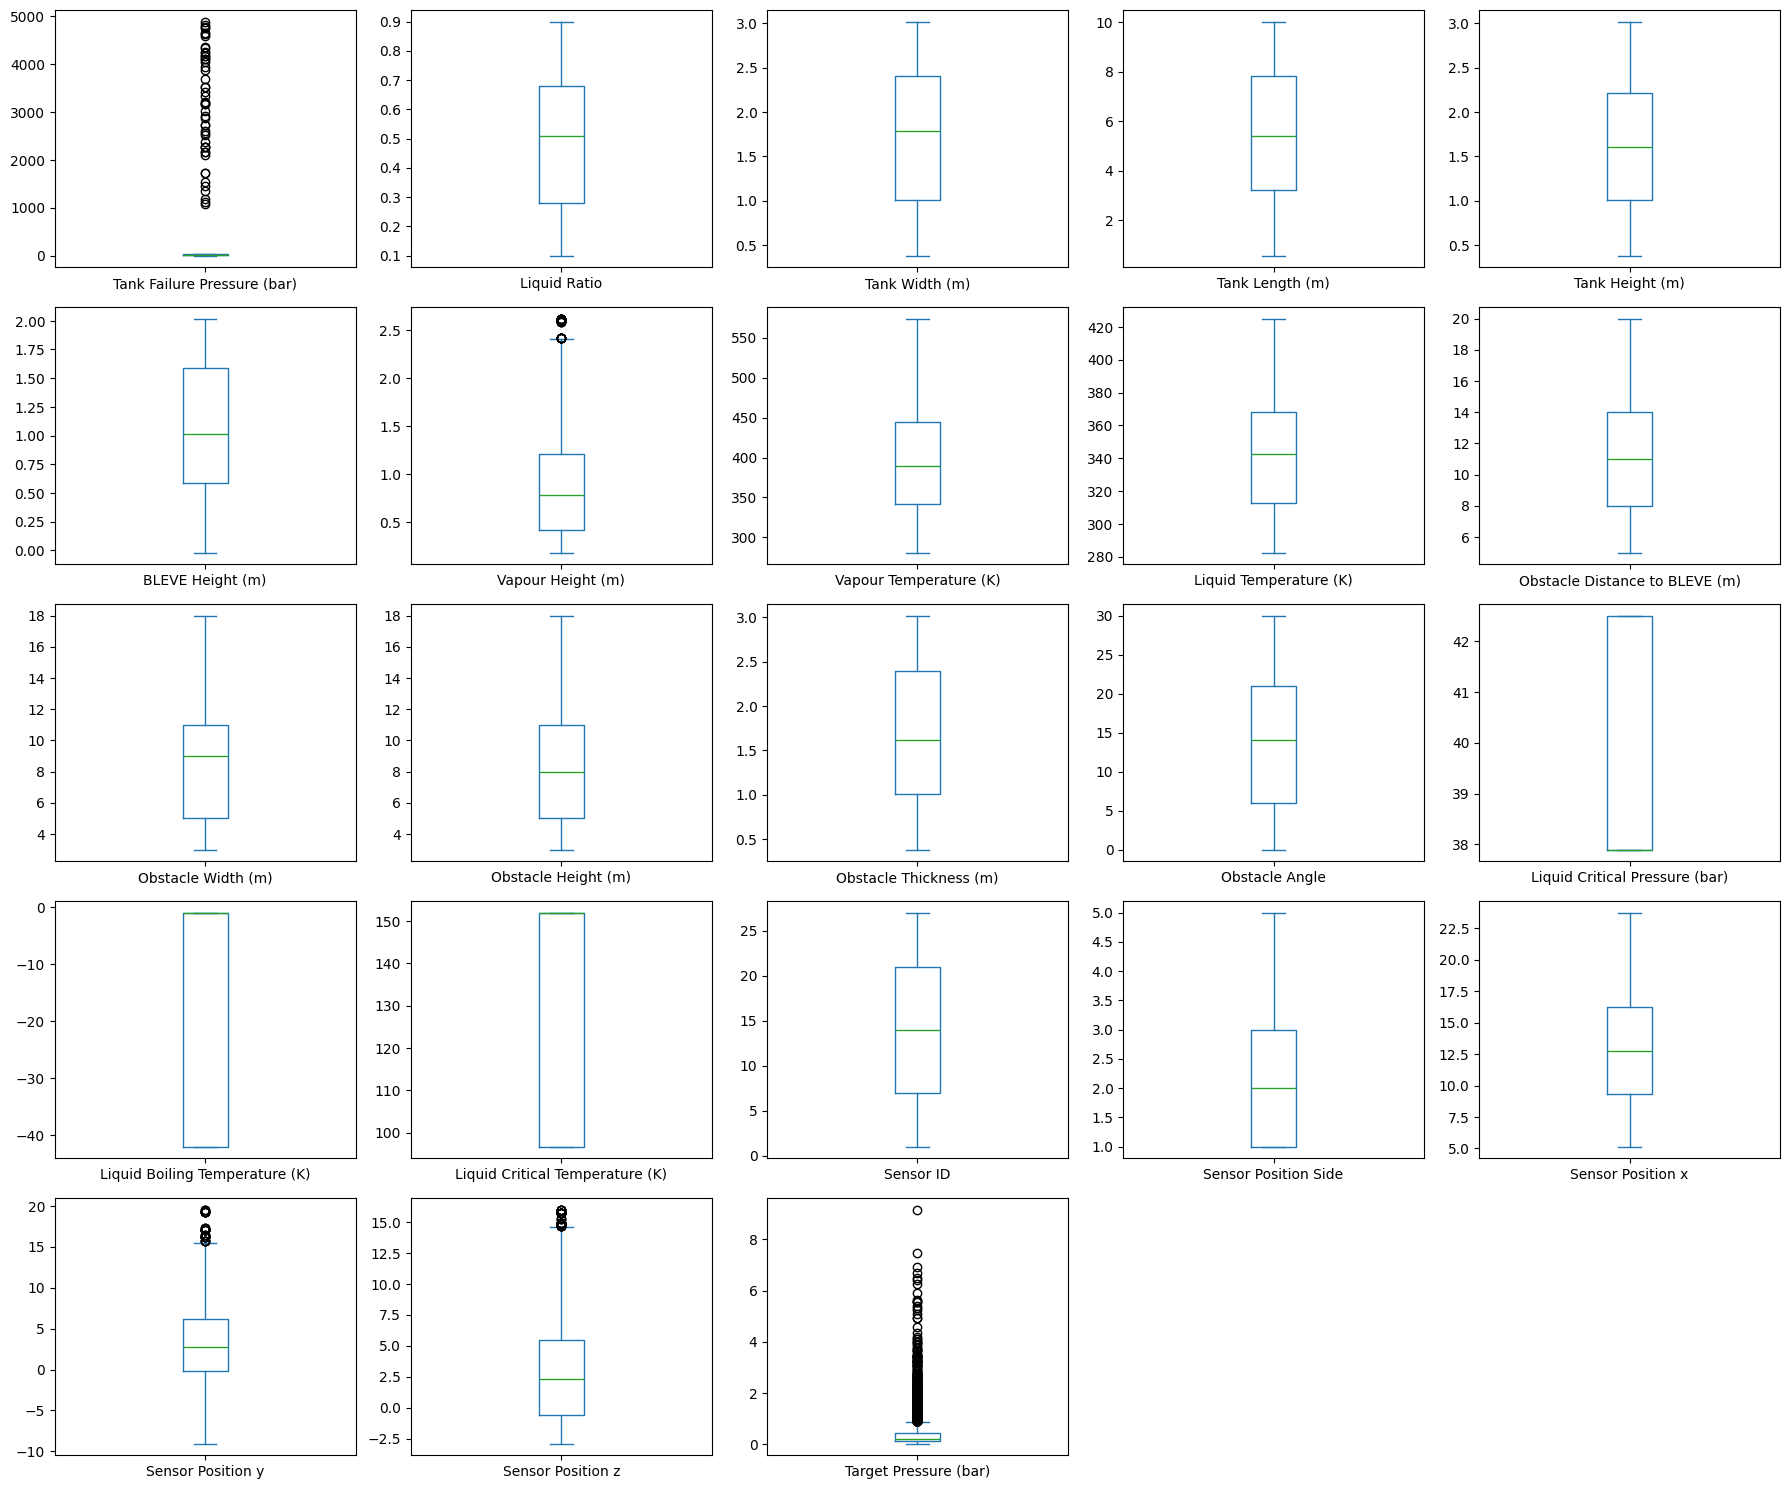

In [14]:
train.select_dtypes(include='number').plot(
    kind='box', subplots=True, layout=(5,5), figsize=(18,15))
plt.tight_layout()
plt.show()

- Tank Failure Pressure: extreme outliers
- Vapour Height: outlier
- Sensor Position y: outlier
- Target Pressure: outlier and skewness
- Liquid Critical Pressure, Liquid Boiling Temperature, Liquid Critical Temperature: narrow range, no median visible implying that most-all of the data has similar value

### 1.2b Target variable distribution

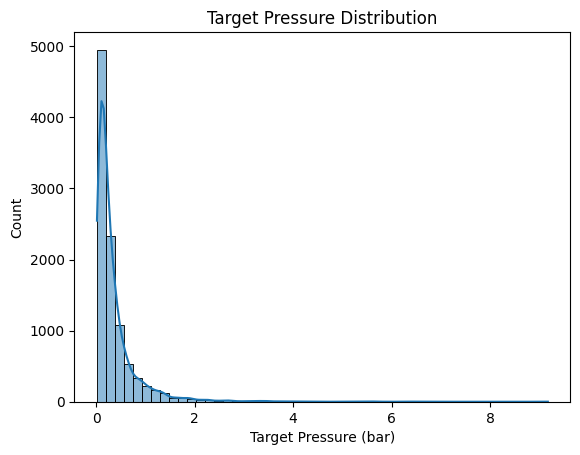

In [15]:
sns.histplot(train['Target Pressure (bar)'], bins=50, kde=True)
plt.title('Target Pressure Distribution')
plt.show()

Given the significant right-skew of the target variable, applying a transformation later is essential to prevent model bias and ensure the algorithm converges effectively.

# 2. DATA PREPROCESSING

## 2.1 Data Cleaning

### 2.1a Handle Duplication

In [16]:
# Drop duplication
train.drop_duplicates(inplace=True)

### 2.1b Handle Missing Value

#### Dependent Variable

Dependent Variables
Target Pressure's missing entries will be dropped instead of being imputed to avoid mislead the model.

In [17]:
train = train.dropna(subset=['Target Pressure (bar)'])

#### Independent Variables

Numerical and categorical will have different imputation strategies. Firstly, check for which column should belong which type

In [18]:
for col in train.columns:
    print(f"{col}: {train[col].nunique()} unique")

Tank Failure Pressure (bar): 3200 unique
Liquid Ratio: 81 unique
Tank Width (m): 70 unique
Tank Length (m): 235 unique
Tank Height (m): 70 unique
BLEVE Height (m): 55 unique
Vapour Height (m): 65 unique
Vapour Temperature (K): 7902 unique
Liquid Temperature (K): 6509 unique
Obstacle Distance to BLEVE (m): 16 unique
Obstacle Width (m): 16 unique
Obstacle Height (m): 16 unique
Obstacle Thickness (m): 70 unique
Obstacle Angle: 31 unique
Status: 8 unique
Liquid Critical Pressure (bar): 2 unique
Liquid Boiling Temperature (K): 2 unique
Liquid Critical Temperature (K): 2 unique
Sensor ID: 27 unique
Sensor Position Side: 5 unique
Sensor Position x: 303 unique
Sensor Position y: 407 unique
Sensor Position z: 182 unique
Target Pressure (bar): 9993 unique


- Liquid Critical Pressure: only 2 unique values — this is essentially a binary indicator of substance type, treat as categorical
- Liquid Boiling Temperature: only 2 unique values — same, categorical
- Liquid Critical Temperature: only 2 unique values — same, categorical
- Status: only 8 unique but it's already a string column — however 8 is suspicious for a binary superheated/subcooled field, worth checking if there are dirty values like extra spaces or capitalisation variants
- Sensor Position Side: 5 unique but should only be 3 (front/back/side) — this is suspicious, may have dirty values or encoding issues, check with value_counts()
- Obstacle Distance to BLEVE, Obstacle Width, Obstacle Height: all exactly 16 unique — this is clearly a designed discrete grid in the simulation, not continuous. Treat as numerical but note this
- Sensor ID: 27 unique — exactly matches the 27 sensors described in the assignment, treat as categorical label not a number
- Tank Width, Tank Height: both 70 unique same discrete simulation grid pattern
Obstacle Angle: 31 unique — discrete but enough values to treat as numerical

In [19]:
# --- Numerical columns: impute with MEDIAN (robust to outliers) ---
numerical_cols = ['Tank Failure Pressure (bar)',
                  'Liquid Ratio',
                  'Tank Width (m)',
                  'Tank Length (m)',
                  'Tank Height (m)',
                  'BLEVE Height (m)',
                  'Vapour Height (m)',
                  'Vapour Temperature (K)',
                  'Liquid Temperature (K)',
                  'Obstacle Distance to BLEVE (m)',
                  'Obstacle Width (m)',
                  'Obstacle Height (m)',
                  'Obstacle Thickness (m)',
                  'Obstacle Angle',
                  'Sensor Position x',
                  'Sensor Position y',
                  'Sensor Position z']
for col in numerical_cols:
    train[col] = train[col].fillna(train[col].median())

In [20]:
# --- Categorical columns: check values then decide suitable imputation strategy ---
categorical_col = ['Liquid Critical Pressure (bar)',
             'Liquid Boiling Temperature (K)',
             'Liquid Critical Temperature (K)',
             'Status',
             'Sensor Position Side',
             'Sensor ID']

def value_check(data, col_name):
    print(f"{'='*50}")
    print(data[col_name].value_counts())
    print(f"Total of unique values: {data[col_name].nunique()}")

for col in categorical_col:
    value_check(train, col)

Liquid Critical Pressure (bar)
37.9    5395
42.5    4576
Name: count, dtype: int64
Total of unique values: 2
Liquid Boiling Temperature (K)
-1.0     5393
-42.0    4578
Name: count, dtype: int64
Total of unique values: 2
Liquid Critical Temperature (K)
152.0    5389
96.7     4581
Name: count, dtype: int64
Total of unique values: 2
Status
Subcooled      6176
Superheated    3735
subcooled        23
Subcool          17
Subcoled         14
Saperheated      10
superheated       9
Superheat         7
Name: count, dtype: int64
Total of unique values: 8
Sensor Position Side
1.0    3329
2.0    3328
5.0    1112
3.0    1111
4.0    1110
Name: count, dtype: int64
Total of unique values: 5
Sensor ID
18.0    371
20.0    371
22.0    371
26.0    371
27.0    371
25.0    371
19.0    370
21.0    370
24.0    370
1.0     370
2.0     370
17.0    370
3.0     370
4.0     370
5.0     370
7.0     370
8.0     370
9.0     370
13.0    370
16.0    370
12.0    370
15.0    370
23.0    369
6.0     369
11.0    369
10.0  

In [21]:
# Categorical features shall be imputed with mode
def cat_impute(data, col_name):
    data[col_name] = data[col_name].fillna(data[col_name].mode()[0])

In [22]:
# --- Substance-type columns: infer from each other ---
# These 3 columns always come in pairs based on substance type
train.groupby('Liquid Critical Pressure (bar)')[
    ['Liquid Boiling Temperature (K)', 'Liquid Critical Temperature (K)']
].mean()

,Liquid Boiling Temperature (K),Liquid Critical Temperature (K)
Liquid Critical Pressure (bar),,
37.9,-1.0,152.0
42.5,-42.0,96.7


When Pressure is 37.9, boiling temp is -1.0 and critical temp is 152.0
When Pressure is 42.5, boiling temp is -42.0 and critical temp is 96.7

In [23]:
def impute_substance_cols(df):
    mask_379 = df['Liquid Critical Pressure (bar)'] == 37.9
    mask_425 = df['Liquid Critical Pressure (bar)'] == 42.5
    df.loc[mask_379, 'Liquid Boiling Temperature (K)'] = -1.0
    df.loc[mask_379, 'Liquid Critical Temperature (K)'] = 152.0
    df.loc[mask_425, 'Liquid Boiling Temperature (K)'] = -42.0
    df.loc[mask_425, 'Liquid Critical Temperature (K)'] = 96.7
    return df

cat_impute(train, 'Liquid Critical Pressure (bar)')
train = impute_substance_cols(train)

In [24]:
# --- Status column: fix typos then impute with mode ---
train["Status"] = train["Status"].replace(
    {'subcooled': 'Subcooled',
     'Subcool': 'Subcooled',
     'Subcoled': 'Subcooled',
     'Saperheated': 'Superheated',
     'superheated': 'Superheated',
     'Superheat': 'Superheated'})
train = train[train['Status'] != 0]
train = train.reset_index(drop=True)
cat_impute(train, 'Status')
value_check(train, 'Status') # double check again

Status
Subcooled      6233
Superheated    3761
Name: count, dtype: int64
Total of unique values: 2


The assignment specification describes 3 sensor wall positions (front, back, side). However the data contains 5 unique values for Sensor Position Side. Values 1 and 2 each contain ~3330 rows while values 3, 4, and 5 each contain ~1110 rows. Notably 1110 × 3 ≈ 3330, suggesting the side wall was subdivided into 3 groups. Therefore, investigate sensor ID distribution across these groups to confirm whether they represent sub-divisions of the same physical wall before deciding on the encoding strategy.

In [25]:
# Investigate the sensor IDs within each Sensor Position Side group
print(train.groupby('Sensor Position Side')['Sensor ID'].unique().apply(sorted))

Sensor Position Side
1.0        [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
2.0    [10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17....
3.0                                   [19.0, 20.0, 21.0]
4.0                                   [22.0, 23.0, 24.0]
5.0                                   [25.0, 26.0, 27.0]
Name: Sensor ID, dtype: object


Sensor Position Side contains 5 unique values instead of 3 as described
in the assignment spec. Investigation reveals:
- Side 1 (front): sensors 1-9
- Side 2 (back): sensors 10-18  
- Sides 3,4,5 (side wall subdivisions): sensors 19-21, 22-24, 25-27

The side wall (9 sensors total) is subdivided into 3 groups of 3 sensors,
likely representing different spatial positions on the wall. These are kept
as separate categories to preserve spatial information.

In [26]:
# --- Sensor position side column: impute with mode ---
cat_impute(train, 'Sensor Position Side')

In [27]:
# --- Sensor ID column: impute with mode ---
cat_impute(train, 'Sensor ID')

In [28]:
# double check after imputation
explore_data(train, "Train Set")

  Train Set
Shape     : 9994 rows x 24 columns
Duplicates: 0

Null Values:
  No null values found.


## 2.2 Data Type Conversion

In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Tank Failure Pressure (bar)      9994 non-null   float64
 1   Liquid Ratio                     9994 non-null   float64
 2   Tank Width (m)                   9994 non-null   float64
 3   Tank Length (m)                  9994 non-null   float64
 4   Tank Height (m)                  9994 non-null   float64
 5   BLEVE Height (m)                 9994 non-null   float64
 6   Vapour Height (m)                9994 non-null   float64
 7   Vapour Temperature (K)           9994 non-null   float64
 8   Liquid Temperature (K)           9994 non-null   float64
 9   Obstacle Distance to BLEVE (m)   9994 non-null   float64
 10  Obstacle Width (m)               9994 non-null   float64
 11  Obstacle Height (m)              9994 non-null   float64
 12  Obstacle Thickness (

In [30]:
for col in categorical_col:
  value_check(train, col)

Liquid Critical Pressure (bar)
37.9    5418
42.5    4576
Name: count, dtype: int64
Total of unique values: 2
Liquid Boiling Temperature (K)
-1.0     5418
-42.0    4576
Name: count, dtype: int64
Total of unique values: 2
Liquid Critical Temperature (K)
152.0    5418
96.7     4576
Name: count, dtype: int64
Total of unique values: 2
Status
Subcooled      6233
Superheated    3761
Name: count, dtype: int64
Total of unique values: 2
Sensor Position Side
1.0    3333
2.0    3328
5.0    1112
3.0    1111
4.0    1110
Name: count, dtype: int64
Total of unique values: 5
Sensor ID
18.0    374
20.0    371
22.0    371
26.0    371
27.0    371
25.0    371
19.0    370
21.0    370
24.0    370
1.0     370
2.0     370
17.0    370
3.0     370
4.0     370
5.0     370
7.0     370
8.0     370
9.0     370
13.0    370
16.0    370
12.0    370
15.0    370
23.0    369
6.0     369
11.0    369
10.0    369
14.0    369
Name: count, dtype: int64
Total of unique values: 27


In [31]:
binary_col = ["Liquid Critical Pressure (bar)",
              "Liquid Boiling Temperature (K)",
              "Liquid Critical Temperature (K)",
              "Status"]

In [32]:
def binary_encode(data, col_name):
    unique_vals = sorted(data[col_name].unique())  # sorted for consistency
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    print(f"{col_name} mapping: {mapping}")  # know what 0/1 means
    data[col_name] = data[col_name].map(mapping)
    return data
for col in binary_col:
    train = binary_encode(train, col)
    test = binary_encode(test, col)


Liquid Critical Pressure (bar) mapping: {np.float64(37.9): 0, np.float64(42.5): 1}
Liquid Critical Pressure (bar) mapping: {np.float64(37.9): 0, np.float64(42.5): 1}
Liquid Boiling Temperature (K) mapping: {np.float64(-42.0): 0, np.float64(-1.0): 1}
Liquid Boiling Temperature (K) mapping: {np.int64(-42): 0, np.int64(-1): 1}
Liquid Critical Temperature (K) mapping: {np.float64(96.7): 0, np.float64(152.0): 1}
Liquid Critical Temperature (K) mapping: {np.float64(96.7): 0, np.float64(152.0): 1}
Status mapping: {'Subcooled': 0, 'Superheated': 1}
Status mapping: {'Subcooled': 0, 'Superheated': 1}


In [33]:
for col in ['Sensor ID','Sensor Position Side']:
    train[col] = train[col].astype(int)
    test[col] = test[col].astype(int)

In [34]:
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (9994, 24)
Test: (3203, 23)


Column 'Sensor ID' will be kept as numeric

In [35]:
encoder = OneHotEncoder(sparse_output=False, dtype=int)
encoded = encoder.fit_transform(train[['Sensor Position Side']])
encoded_cols = encoder.get_feature_names_out(['Sensor Position Side'])
train[encoded_cols] = encoded
test[encoded_cols] = encoder.transform(test[['Sensor Position Side']])
train = train.drop(columns=['Sensor Position Side'])
test = test.drop(columns=['Sensor Position Side'])

In [36]:
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (9994, 28)
Test: (3203, 27)


In [37]:
train.head(10)

,Tank Failure Pressure (bar),Liquid Ratio,Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),Obstacle Distance to BLEVE (m),Obstacle Width (m),Obstacle Height (m),Obstacle Thickness (m),Obstacle Angle,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar),Sensor Position Side_1,Sensor Position Side_2,Sensor Position Side_3,Sensor Position Side_4,Sensor Position Side_5
0,14.26,0.25,1.58,8.61,1.79,1.01,1.40,457.14,423.07,19.0,11.0,5.0,0.39,1.0,1,0,1,1,18,19.75,5.70,3.1,0.588298,0,1,0,0,0
1,14.14,0.25,1.59,8.58,1.81,1.00,1.41,457.71,422.82,19.0,11.0,5.0,0.40,1.0,1,0,1,1,19,20.00,-5.15,-1.5,0.551524,0,0,1,0,0
2,14.05,0.24,1.62,8.59,1.79,0.98,1.38,456.58,422.37,19.0,11.0,5.0,0.40,1.0,1,0,1,1,20,20.00,-5.15,0.8,0.550813,0,0,1,0,0
3,14.17,0.24,1.59,8.60,1.80,0.98,1.40,456.81,423.28,19.0,11.0,5.0,0.42,1.0,1,0,1,1,21,20.00,-5.15,3.1,0.528906,0,0,1,0,0
4,14.09,0.24,1.59,8.60,1.80,1.00,1.40,456.93,423.19,19.0,11.0,5.0,0.39,1.0,1,0,1,1,22,20.00,-4.90,3.4,0.454363,0,0,0,1,0
5,14.22,0.25,1.62,8.59,1.82,1.01,1.40,457.58,422.58,19.0,11.0,5.0,0.39,1.0,1,0,1,1,23,20.00,0.40,3.4,0.291131,0,0,0,1,0
6,14.24,0.25,1.60,8.62,1.81,0.98,1.40,457.76,422.29,19.0,11.0,5.0,0.39,1.0,1,0,1,1,24,20.00,5.70,3.4,0.276944,0,0,0,1,0
7,14.06,0.25,1.59,8.59,1.81,1.00,1.39,457.11,422.47,19.0,11.0,5.0,0.39,1.0,1,0,1,1,25,20.00,5.95,-1.5,0.257186,0,0,0,0,1
8,14.11,0.25,1.60,8.62,1.80,1.01,1.40,456.22,422.64,19.0,11.0,5.0,0.40,1.0,1,0,1,1,26,20.00,5.95,0.8,0.257603,0,0,0,0,1
9,14.04,0.24,1.61,8.61,1.82,1.01,1.39,457.14,422.54,19.0,11.0,5.0,0.39,1.0,1,0,1,1,27,20.00,5.95,3.1,0.257005,0,0,0,0,1


## 2.3 Outlier Detection

Outlier detection is applied using z-score method

In [38]:
def z_score_outliers(df, cols, threshold=3):
    print(f"{'='*50}")
    print("Outlier Detection")
    cleaned_df = df.copy()
    total_rows = len(df)
    for col in cols:
        z = np.abs(stats.zscore(cleaned_df[col]))
        outlier_indices = np.where(z > threshold)[0]
        num_outliers = len(outlier_indices)
        if num_outliers > 0:
            fraction_outliers = num_outliers / total_rows * 100
            print(f"Column '{col}': {num_outliers} outliers, equivalent to {fraction_outliers:.4f}%")

    # Remove all outliers in one go, to prevent progressive filtering issues
    combined_filtered_val = pd.Series([True] * total_rows, index=cleaned_df.index)
    for col in cols:
        z = np.abs(stats.zscore(cleaned_df[col]))
        combined_filtered_val = combined_filtered_val & (z < threshold)
    cleaned_df = cleaned_df[combined_filtered_val]
    print(f"\nOriginal shape: {df.shape}")
    print(f"Cleaned shape: {cleaned_df.shape}")
    print(f"{'='*50}")
    return cleaned_df

train_df = z_score_outliers(train,numerical_cols)

Outlier Detection
Column 'Tank Failure Pressure (bar)': 50 outliers, equivalent to 0.5003%
Column 'Vapour Height (m)': 27 outliers, equivalent to 0.2702%
Column 'Sensor Position y': 20 outliers, equivalent to 0.2001%
Column 'Sensor Position z': 6 outliers, equivalent to 0.0600%

Original shape: (9994, 28)
Cleaned shape: (9891, 28)


## 2.4 Feature Engineering

Feature engineering is performed before feature correlation analysis.
New features are created based on physical domain knowledge of BLEVE
dynamics without pre-filtering for redundancy. The subsequent feature
correlation and selection step will data-drivenly determine which
engineered features provide additional predictive value beyond the
original features.

### 2.4a Tank Geometry — physical size features

In [39]:
# --- Tank Volume: total internal volume of the tank (m³)
# Larger volume means more stored energy and potentially stronger blast
train['Tank Volume'] = train['Tank Width (m)'] * train['Tank Length (m)'] * train['Tank Height (m)']
test['Tank Volume'] = test['Tank Width (m)'] * test['Tank Length (m)'] * test['Tank Height (m)']

# --- Tank Aspect Ratio: height relative to width (H/W)
# High ratio = tall narrow tank, low ratio = short wide tank
# Affects how the BLEVE energy is directed vertically vs horizontally
train['Tank Aspect Ratio'] = train['Tank Height (m)'] / train['Tank Width (m)']
test['Tank Aspect Ratio'] = test['Tank Height (m)'] / test['Tank Width (m)']

# --- Vapour Ratio: proportion of tank occupied by vapour (complement of liquid ratio)
# Higher vapour ratio means more compressible gas available to expand during BLEVE
train['Vapour Ratio'] = 1 - train['Liquid Ratio']
test['Vapour Ratio'] = 1 - test['Liquid Ratio']

# --- Vapour Volume: actual volume of vapour inside the tank (m³)
# Directly relates to the amount of expanding gas driving the blast wave
train['Vapour Volume'] = train['Tank Volume'] * train['Vapour Ratio']
test['Vapour Volume'] = test['Tank Volume'] * test['Vapour Ratio']

### 2.4b Obstacle Geometry

In [40]:
# --- Obstacle Face Area: the surface area facing the blast wave (m²)
# Larger face area intercepts more of the blast wave, affecting reflection intensity
train['Obstacle Face Area'] = train['Obstacle Width (m)'] * train['Obstacle Height (m)']
test['Obstacle Face Area'] = test['Obstacle Width (m)'] * test['Obstacle Height (m)']

# --- Obstacle Volume: total volume of the obstacle (m³)
# Larger obstacle volume means more mass to reflect and deflect blast energy
train['Obstacle Volume'] = train['Obstacle Width (m)'] * train['Obstacle Height (m)'] * train['Obstacle Thickness (m)']
test['Obstacle Volume'] = test['Obstacle Width (m)'] * test['Obstacle Height (m)'] * test['Obstacle Thickness (m)']


### 2.4c Temperature & Pressure — thermodynamic features

In [41]:
# --- Temperature Difference: difference between vapour and liquid temperature (K)
# Large difference indicates greater thermodynamic instability, more violent BLEVE
train['Temp Difference'] = train['Vapour Temperature (K)'] - train['Liquid Temperature (K)']
test['Temp Difference'] = test['Vapour Temperature (K)'] - test['Liquid Temperature (K)']

# --- Pressure Ratio: tank failure pressure relative to substance critical pressure
# How far above critical pressure the tank was — higher ratio means more extreme BLEVE
train['Pressure Ratio'] = train['Tank Failure Pressure (bar)'] / train['Liquid Critical Pressure (bar)']
test['Pressure Ratio'] = test['Liquid Critical Pressure (bar)'] / test['Liquid Critical Pressure (bar)']

### 2.4d Energy proxy

In [42]:
# --- BLEVE Energy Proxy: product of failure pressure and tank volume (bar·m³)
# Approximates the total stored energy released during the explosion
train['BLEVE Energy Proxy'] = train['Tank Failure Pressure (bar)'] * train['Tank Volume']
test['BLEVE Energy Proxy'] = test['Tank Failure Pressure (bar)'] * test['Tank Volume']

In [43]:
numerical_cols.extend(["Tank Volume","Tank Aspect Ratio","Vapour Ratio","Vapour Volume",
                      "Obstacle Face Area","Obstacle Volume","Temp Difference","Pressure Ratio","BLEVE Energy Proxy"])

In [44]:
print(f"Numerical columns: {numerical_cols}")

Numerical columns: ['Tank Failure Pressure (bar)', 'Liquid Ratio', 'Tank Width (m)', 'Tank Length (m)', 'Tank Height (m)', 'BLEVE Height (m)', 'Vapour Height (m)', 'Vapour Temperature (K)', 'Liquid Temperature (K)', 'Obstacle Distance to BLEVE (m)', 'Obstacle Width (m)', 'Obstacle Height (m)', 'Obstacle Thickness (m)', 'Obstacle Angle', 'Sensor Position x', 'Sensor Position y', 'Sensor Position z', 'Tank Volume', 'Tank Aspect Ratio', 'Vapour Ratio', 'Vapour Volume', 'Obstacle Face Area', 'Obstacle Volume', 'Temp Difference', 'Pressure Ratio', 'BLEVE Energy Proxy']


In [45]:
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (9994, 37)
Test: (3203, 36)


## 2.5 Feature Selection

### 2.5a Correlation with Target

In [46]:
target_corr = train.corr()['Target Pressure (bar)'].abs().sort_values(ascending=False)
print(target_corr)

Target Pressure (bar)              1.000000
Sensor Position Side_2             0.485986
Vapour Volume                      0.364870
Sensor Position Side_1             0.354118
Sensor Position x                  0.295999
Tank Volume                        0.279953
Vapour Height (m)                  0.261447
Obstacle Distance to BLEVE (m)     0.222183
Tank Height (m)                    0.206269
Sensor Position y                  0.190258
Sensor Position z                  0.185605
Tank Length (m)                    0.150132
Vapour Ratio                       0.134235
Liquid Ratio                       0.134235
Obstacle Face Area                 0.131269
Sensor Position Side_5             0.124673
Obstacle Volume                    0.121952
Sensor Position Side_4             0.110329
Obstacle Height (m)                0.096157
BLEVE Height (m)                   0.076132
Liquid Critical Temperature (K)    0.066608
Liquid Boiling Temperature (K)     0.066608
Liquid Critical Pressure (bar)  

Linear correlation with the target is weak for most features,
particularly thermodynamic variables like Tank Failure Pressure
and Vapour Temperature. However, since the relationship between
blast pressure and these physical quantities is highly nonlinear,
linear correlation is not a reliable filter here. No features are
dropped based on target correlation alone. Feature importance from
tree-based models (embedded method) will be used instead to identify
truly uninformative features after model training.

### 2.5b Multicollinearity detection & dropping

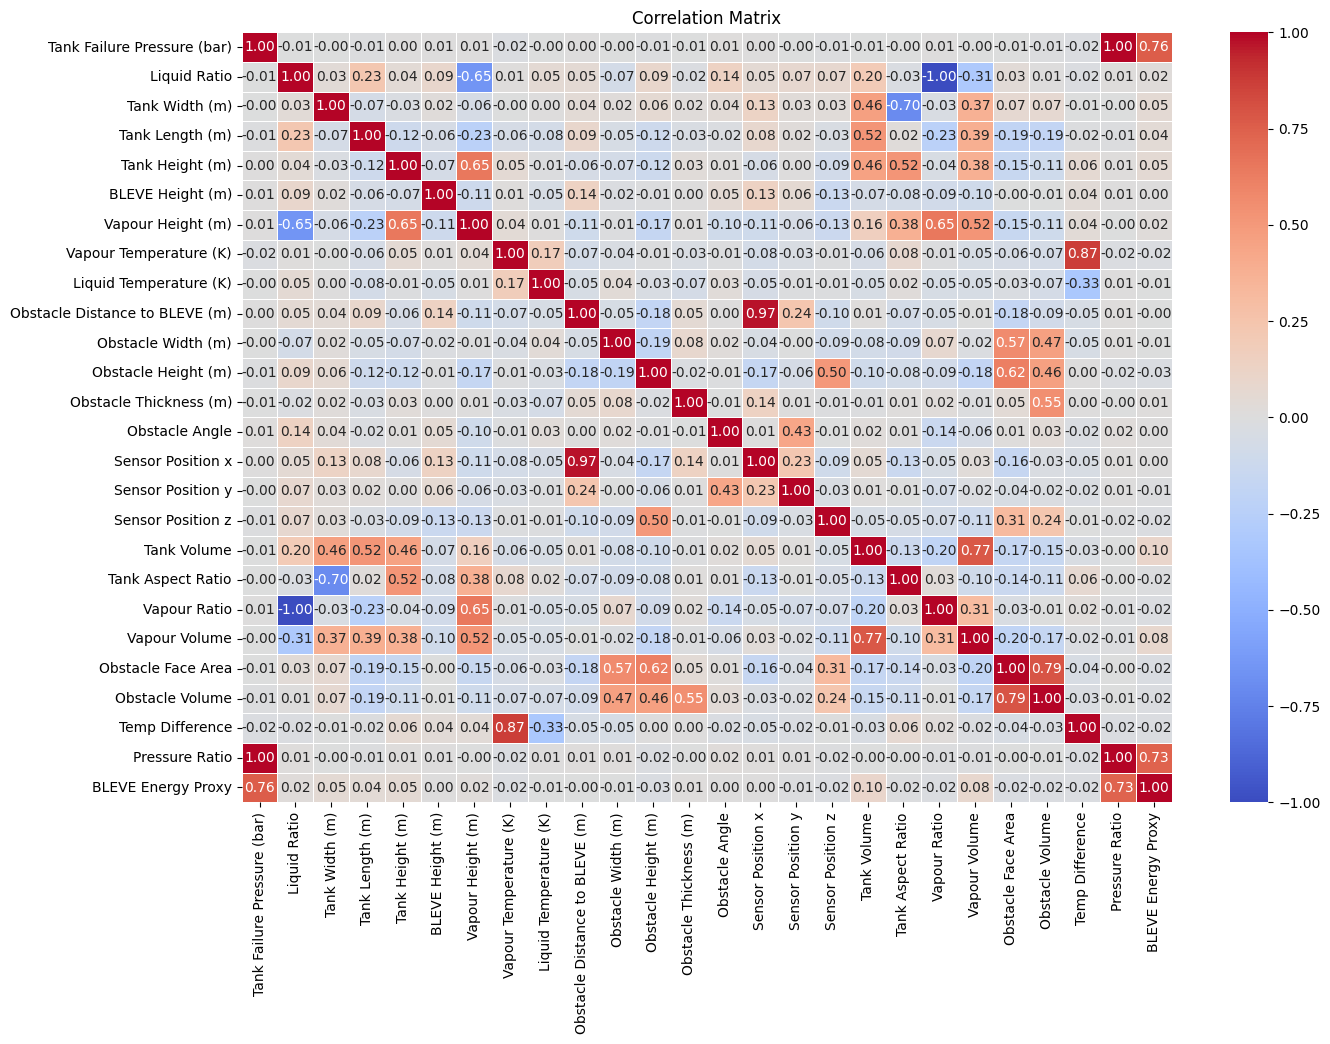

In [47]:
correlation_matrix = train[numerical_cols].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5,fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [48]:
def corr_feature(data, cols, threshold=0.7):
    corr_matrix = data[cols].corr()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

  # Find pairs with correlation > or < threshold
    high_corr_pairs = []
    for col in upper_triangle.columns:
      for row in upper_triangle.index:
          val = upper_triangle.loc[row, col]
          if abs(val) > threshold:
              high_corr_pairs.append((row, col, round(val, 2)))

  # Sort by absolute correlation descending
    high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

    print(f"Pairs with |correlation| > {threshold}:\n")
    for feat1, feat2, corr in high_corr_pairs:
      direction = "positive" if corr > 0 else "negative"
      print(f"  {feat1} vs {feat2}: {corr} ({direction})")

corr_feature(train, numerical_cols)

Pairs with |correlation| > 0.7:

  Liquid Ratio vs Vapour Ratio: -1.0 (negative)
  Tank Failure Pressure (bar) vs Pressure Ratio: 1.0 (positive)
  Obstacle Distance to BLEVE (m) vs Sensor Position x: 0.97 (positive)
  Vapour Temperature (K) vs Temp Difference: 0.87 (positive)
  Obstacle Face Area vs Obstacle Volume: 0.79 (positive)
  Tank Volume vs Vapour Volume: 0.77 (positive)
  Tank Failure Pressure (bar) vs BLEVE Energy Proxy: 0.76 (positive)
  Pressure Ratio vs BLEVE Energy Proxy: 0.73 (positive)


For each pair, the rule is: drop the one that is derived/engineered, keep the one that is original or more physically meaningful.

1. Liquid Ratio vs Vapour Ratio (r = -1.0)

Drop Vapour Ratio. It was engineered as 1 - Liquid Ratio so it is mathematically identical. Liquid Ratio is the original feature.

2. Tank Failure Pressure vs Pressure Ratio (r = 1.0)

Drop Pressure Ratio. It was engineered as Tank Failure Pressure / Liquid Critical Pressure. Since Liquid Critical Pressure is binary (only 2 values), dividing by it just rescales Tank Failure Pressure by a constant. No new information added.

3. Obstacle Distance to BLEVE vs Sensor Position x (r = 0.97)

Drop Sensor Position x. The x-coordinate of the sensor is nearly identical to the obstacle distance because sensors are placed at fixed positions relative to the obstacle. Obstacle Distance to BLEVE is more meaningful as a physical setup parameter. Spatial information is also preserved in Sensor Distance to BLEVE.

4. Vapour Temperature vs Temp Difference (r = 0.87)

Drop Temp Difference. It was engineered as Vapour Temperature - Liquid Temperature. Since Liquid Temperature has relatively low variance compared to Vapour Temperature, the difference is dominated by Vapour Temperature. Both original features are kept separately.

5. Obstacle Face Area vs Obstacle Volume (r = 0.79)

Drop Obstacle Face Area. Obstacle Volume includes thickness which provides additional geometric information. Face area is a subset of what volume captures.

6. Tank Volume vs Vapour Volume (r = 0.77)

Drop Vapour Volume. It was engineered as Tank Volume * Vapour Ratio. Since Tank Volume and Liquid Ratio are both kept separately, Vapour Volume is redundant.

7. Tank Failure Pressure vs BLEVE Energy Proxy (r = 0.76)

Keep both. BLEVE Energy Proxy combines Tank Failure Pressure and Tank Volume together. The moderate correlation suggests Tank Volume contributes meaningfully to the proxy, so it carries some additional information beyond pressure alone.

8. Pressure Ratio vs BLEVE Energy Proxy (r = 0.73)

Resolved by dropping Pressure Ratio in number 2.

In [49]:
cols_to_drop = [
    'Vapour Ratio',        # = 1 - Liquid Ratio, perfectly redundant
    'Pressure Ratio',      # = Tank Failure Pressure / constant, no new info
    'Sensor Position x',   # r=0.97 with Obstacle Distance, spatial info in Sensor Distance
    'Temp Difference',     # r=0.87 with Vapour Temperature, dominated by it
    'Obstacle Face Area',  # r=0.79 with Obstacle Volume, volume is more complete
    'Vapour Volume',       # r=0.77 with Tank Volume, redundant given Liquid Ratio kept
]

train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

# Verify
print(f"Remaining columns ({train.shape[1]}):")
print(train.columns.tolist())

Remaining columns (31):
['Tank Failure Pressure (bar)', 'Liquid Ratio', 'Tank Width (m)', 'Tank Length (m)', 'Tank Height (m)', 'BLEVE Height (m)', 'Vapour Height (m)', 'Vapour Temperature (K)', 'Liquid Temperature (K)', 'Obstacle Distance to BLEVE (m)', 'Obstacle Width (m)', 'Obstacle Height (m)', 'Obstacle Thickness (m)', 'Obstacle Angle', 'Status', 'Liquid Critical Pressure (bar)', 'Liquid Boiling Temperature (K)', 'Liquid Critical Temperature (K)', 'Sensor ID', 'Sensor Position y', 'Sensor Position z', 'Target Pressure (bar)', 'Sensor Position Side_1', 'Sensor Position Side_2', 'Sensor Position Side_3', 'Sensor Position Side_4', 'Sensor Position Side_5', 'Tank Volume', 'Tank Aspect Ratio', 'Obstacle Volume', 'BLEVE Energy Proxy']


In [50]:
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (9994, 31)
Test: (3203, 30)



Correlation matrix:


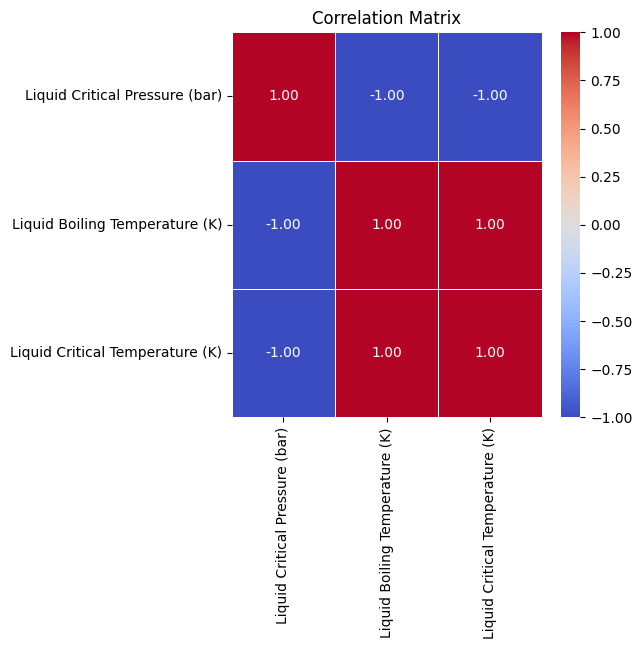


Groupby Liquid Critical Pressure:
                                Liquid Boiling Temperature (K)  \
Liquid Critical Pressure (bar)                                   
0                                                          1.0   
1                                                          0.0   

                                Liquid Critical Temperature (K)  
Liquid Critical Pressure (bar)                                   
0                                                           1.0  
1                                                           0.0  


In [51]:
# Perfect correlation between the 3 substance columns
substance_cols = [
    'Liquid Critical Pressure (bar)',
    'Liquid Boiling Temperature (K)',
    'Liquid Critical Temperature (K)'
]

# 2. Show correlation
print(f"\nCorrelation matrix:")
plt.figure(figsize=(5, 5))
sns.heatmap(train[substance_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5,fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# 3. Show groupby — prove each pressure maps to exactly one boiling and critical temp
print(f"\nGroupby Liquid Critical Pressure:")
print(train.groupby('Liquid Critical Pressure (bar)')[
    ['Liquid Boiling Temperature (K)', 'Liquid Critical Temperature (K)']
].mean())



Retaining all three columns would introduce perfect multicollinearity which can destabilise model training and artificially inflate the apparent importance of substance type by representing it three times. Therefore **Liquid Boiling Temperature** and **Liquid Critical Temperature** are dropped, keeping only **Liquid Critical Pressure** as the single representative of substance type. This reduces redundancy while preserving all substance-related information.

In [52]:
train = train.drop(columns = ['Liquid Boiling Temperature (K)', 'Liquid Critical Temperature (K)'])
test = test.drop(columns = ['Liquid Boiling Temperature (K)', 'Liquid Critical Temperature (K)'])

In [53]:
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (9994, 29)
Test: (3203, 28)


### 2.5c Embedded Selection

Random Forest regressor is used as an embedded feature selection method. Random Forest captures nonlinear
interactions and provides feature importance scores based on how much each feature
reduces prediction error across all trees, making it well-suited for this problem.

Features with near-zero importance are candidates for removal as they contribute
no predictive value even in a nonlinear context.

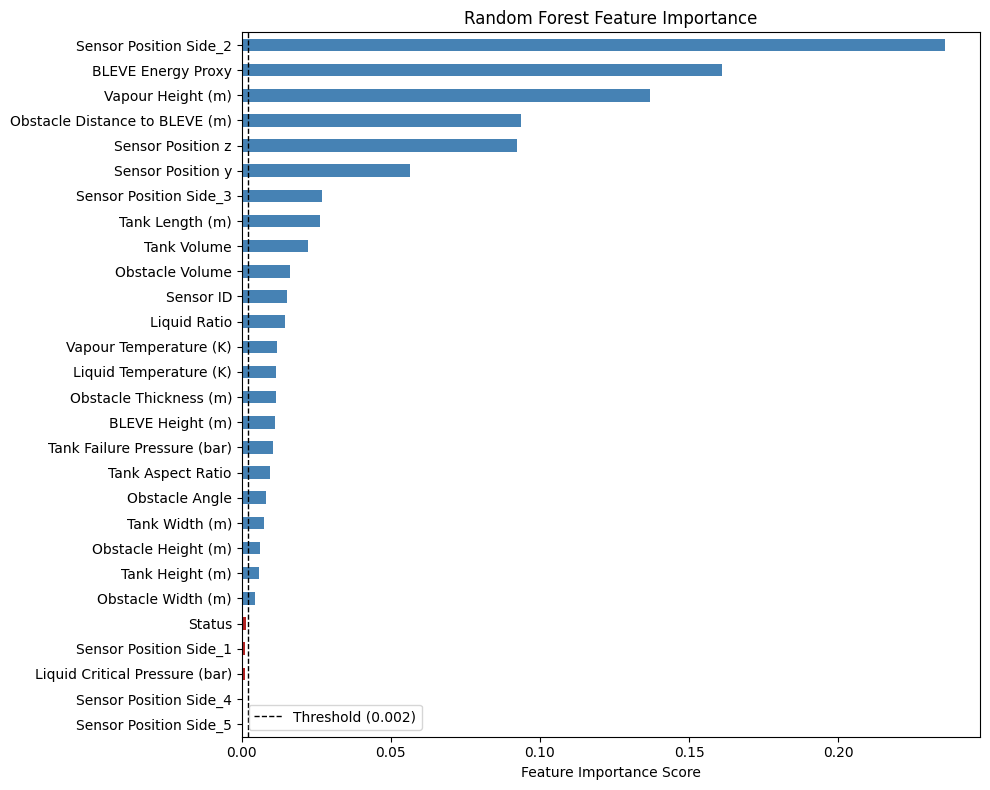


Feature Importance Scores:
  Sensor Position Side_2: 0.2358
  BLEVE Energy Proxy: 0.1610
  Vapour Height (m): 0.1369
  Obstacle Distance to BLEVE (m): 0.0936
  Sensor Position z: 0.0924
  Sensor Position y: 0.0563
  Sensor Position Side_3: 0.0269
  Tank Length (m): 0.0263
  Tank Volume: 0.0222
  Obstacle Volume: 0.0163
  Sensor ID: 0.0153
  Liquid Ratio: 0.0147
  Vapour Temperature (K): 0.0119
  Liquid Temperature (K): 0.0115
  Obstacle Thickness (m): 0.0114
  BLEVE Height (m): 0.0113
  Tank Failure Pressure (bar): 0.0105
  Tank Aspect Ratio: 0.0095
  Obstacle Angle: 0.0080
  Tank Width (m): 0.0074
  Obstacle Height (m): 0.0062
  Tank Height (m): 0.0059
  Obstacle Width (m): 0.0045
  Status: 0.0016 => consider dropping
  Sensor Position Side_1: 0.0012 => consider dropping
  Liquid Critical Pressure (bar): 0.0012 => consider dropping
  Sensor Position Side_4: 0.0000 => consider dropping
  Sensor Position Side_5: 0.0000 => consider dropping


In [54]:
TARGET = 'Target Pressure (bar)'
X = train.drop(columns=[TARGET])
y = train[TARGET]

# Quick RF for feature importance (not the final tuned model)
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

# Feature importance scores
importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 8))
colors = ['firebrick' if v < 0.002 else 'steelblue' for v in importances]
importances.plot(kind='barh', color=colors)
plt.axvline(x=0.002, color='black', linestyle='--', linewidth=1, label='Threshold (0.002)')
plt.xlabel('Feature Importance Score')
plt.title('Random Forest Feature Importance')
plt.legend()
plt.tight_layout()
plt.show()

# Print scores
print("\nFeature Importance Scores:")
cols_to_drop_rf = []
for feat, score in importances.sort_values(ascending=False).items():
    if score < 0.002:
        cols_to_drop_rf.append(feat)
        print(f"  {feat}: {score:.4f} => consider dropping")
    else:
        print(f"  {feat}: {score:.4f}")

In [55]:
train = train.drop(columns=cols_to_drop_rf, errors='ignore')
test = test.drop(columns=cols_to_drop_rf, errors='ignore')

print(f"Final feature set ({train.shape[1] - 1} features):")
for col in train.drop(columns=[TARGET]).columns:
    print(f"  {col}")

Final feature set (23 features):
  Tank Failure Pressure (bar)
  Liquid Ratio
  Tank Width (m)
  Tank Length (m)
  Tank Height (m)
  BLEVE Height (m)
  Vapour Height (m)
  Vapour Temperature (K)
  Liquid Temperature (K)
  Obstacle Distance to BLEVE (m)
  Obstacle Width (m)
  Obstacle Height (m)
  Obstacle Thickness (m)
  Obstacle Angle
  Sensor ID
  Sensor Position y
  Sensor Position z
  Sensor Position Side_2
  Sensor Position Side_3
  Tank Volume
  Tank Aspect Ratio
  Obstacle Volume
  BLEVE Energy Proxy


In [56]:
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (9994, 24)
Test: (3203, 23)


## 2.6 Train/Test Split

The dataset is split into 80% training and 20% validation. The validation set is used to evaluate model performance during model selection and hyperparameter tuning. The test set (test.csv) is held out entirely and only used for final Kaggle submission.

Note: the split is performed after all preprocessing and feature selection steps to ensure no data leakage occurs between train and validation sets.
The scaler in the next step will be fit only on X_train and applied to X_val and test separately.

In [57]:
#TARGET = 'Target Pressure (bar)'
X = train.drop(columns=[TARGET])
y = train[TARGET]

# Split 1: 80% train_val, 20% test_labeled
X_train_val, X_test_labeled, y_train_val, y_test_labeled = train_test_split(X, y, test_size=0.2, random_state=42)

# Split 2: from train_val → 80% train, 20% val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

print(f"Full dataset    : {X.shape[0]} rows")
print(f"X_train         : {X_train.shape[0]} rows ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"X_val           : {X_val.shape[0]} rows ({X_val.shape[0]/X.shape[0]*100:.1f}%)")
print(f"X_train_val     : {X_train_val.shape[0]} rows ({X_train_val.shape[0]/X.shape[0]*100:.1f}%)")
print(f"X_test_labeled  : {X_test_labeled.shape[0]} rows ({X_test_labeled.shape[0]/X.shape[0]*100:.1f}%)")
print(f"test.csv        : {test.shape[0]} rows (external)")

Full dataset    : 9994 rows
X_train         : 6396 rows (64.0%)
X_val           : 1599 rows (16.0%)
X_train_val     : 7995 rows (80.0%)
X_test_labeled  : 1999 rows (20.0%)
test.csv        : 3203 rows (external)


In [58]:
X_train_val = X_train_val.reset_index(drop=True)
X_test_labeled = X_test_labeled.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
y_train_val    = y_train_val.reset_index(drop=True)
y_test_labeled = y_test_labeled.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)

## 2.7 Feature Scaling

In [59]:
scaler = StandardScaler()
# Fit
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
# Transform
X_val_scaled = pd.DataFrame(scaler.transform(X_val),columns=X_val.columns,index=X_val.index)
X_train_val_scaled = pd.DataFrame(scaler.transform(X_train_val),columns=X_train_val.columns,index=X_train_val.index)
X_test_labeled_scaled = pd.DataFrame(scaler.transform(X_test_labeled),columns=X_test_labeled.columns,index=X_test_labeled.index)
X_scaled = pd.DataFrame(scaler.transform(X),columns=X.columns,index=X.index)
X_test_scaled = pd.DataFrame(scaler.transform(test),columns= test.columns,index=test.index)

# Verify
print(f"Scaler fitted on X_train: {X_train.shape[0]} rows")
print(f"\nTransformed shapes:")
print(f"  X_train_scaled       : {X_train_scaled.shape}")
print(f"  X_val_scaled         : {X_val_scaled.shape}")
print(f"  X_train_val_scaled   : {X_train_val_scaled.shape}")
print(f"  X_test_labeled_scaled: {X_test_labeled_scaled.shape}")
print(f"  X_scaled         : {X_scaled.shape}")
print(f"  X_test_scaled        : {X_test_scaled.shape}")

Scaler fitted on X_train: 6396 rows

Transformed shapes:
  X_train_scaled       : (6396, 23)
  X_val_scaled         : (1599, 23)
  X_train_val_scaled   : (7995, 23)
  X_test_labeled_scaled: (1999, 23)
  X_scaled         : (9994, 23)
  X_test_scaled        : (3203, 23)


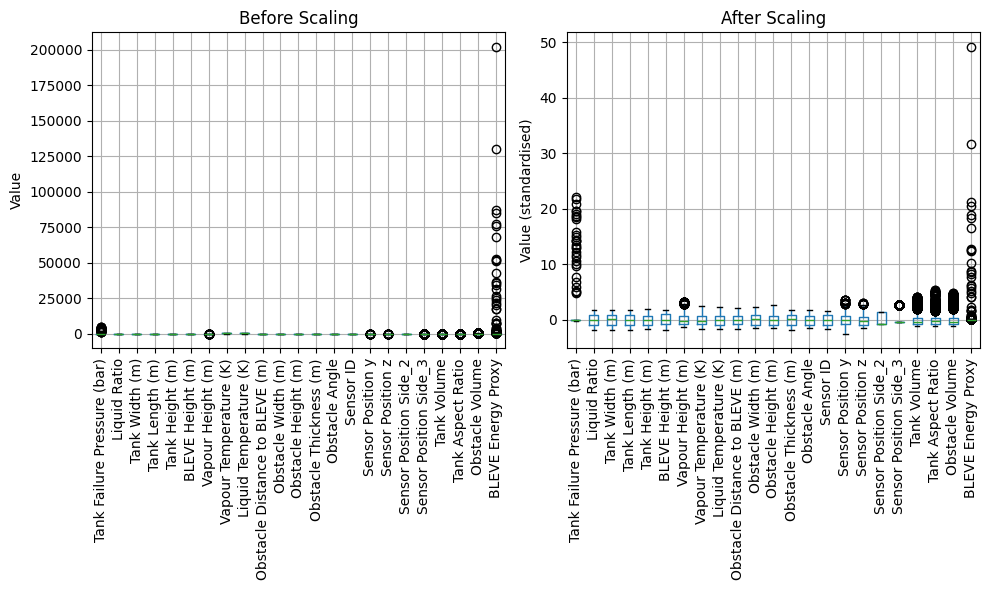

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Before scaling
X_train.boxplot(ax=axes[0], rot=90)
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

# After scaling
X_train_scaled.boxplot(ax=axes[1], rot=90)
axes[1].set_title('After Scaling')
axes[1].set_ylabel('Value (standardised)')

plt.tight_layout()
plt.show()

In [61]:
y_train_val_log = np.log1p(y_train_val)
y_test_labeled_log = np.log1p(y_test_labeled)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_log = np.log1p(y)

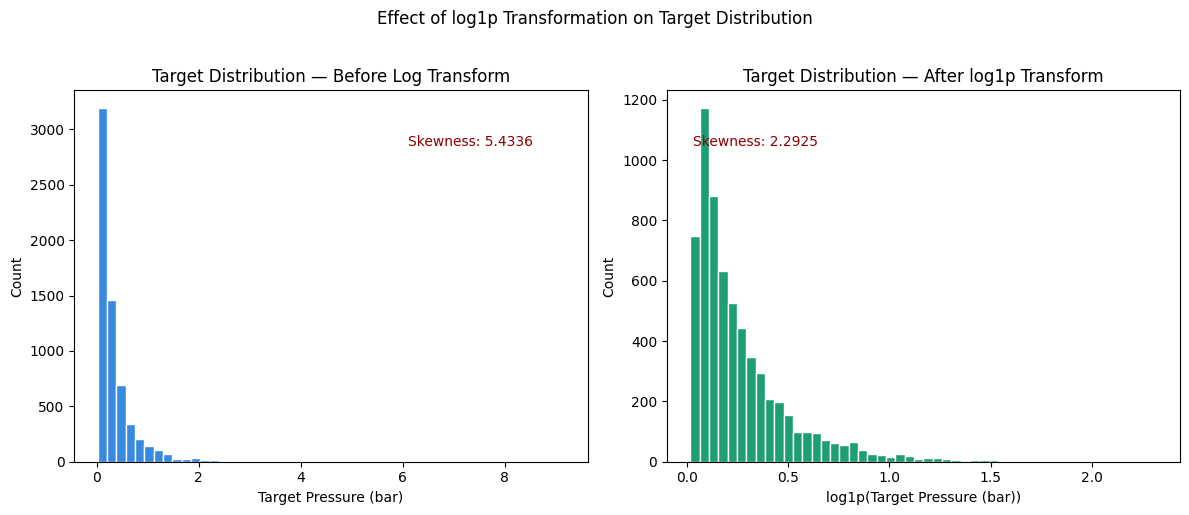

Before log — skewness: 5.4336
After log  — skewness: 2.2925


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before log transform
axes[0].hist(y_train, bins=50, color='#378ADD', edgecolor='white')
axes[0].set_title('Target Distribution — Before Log Transform')
axes[0].set_xlabel('Target Pressure (bar)')
axes[0].set_ylabel('Count')
axes[0].annotate(f'Skewness: {y_train.skew():.4f}',
                  xy=(0.65, 0.85), xycoords='axes fraction',
                  fontsize=10, color='darkred')

# After log transform
axes[1].hist(y_train_log, bins=50, color='#1D9E75', edgecolor='white')
axes[1].set_title('Target Distribution — After log1p Transform')
axes[1].set_xlabel('log1p(Target Pressure (bar))')
axes[1].set_ylabel('Count')
axes[1].annotate(f'Skewness: {y_train_log.skew():.4f}',
                  xy=(0.05, 0.85), xycoords='axes fraction',
                  fontsize=10, color='darkred')

plt.suptitle('Effect of log1p Transformation on Target Distribution',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"Before log — skewness: {y_train.skew():.4f}")
print(f"After log  — skewness: {y_train_log.skew():.4f}")

# 3. MODEL CONSTRUCTION

## 3.1 Model Selection

Due to the weak linear relationships observed between features and target in Section 2.5a, four models representing diverse learning paradigms are examined: gradient boosting (XGBoost, LightGBM, CatBoost) and neural networks (MLP). This ensures a wide variety of fundamentally different approaches are compared rather than minor variants of the same algorithm. For XGBoost and LightGBM, early stopping is applied after tuning to find the optimal number of estimators, preventing overfitting from excessive tree growth.

## 3.2 Cross Validation for Best Parameters

Hyperparameter tuning is performed using RandomizedSearchCV rather than GridSearchCV. Unlike GridSearchCV which exhaustively evaluates every possible parameter combination, RandomizedSearchCV samples a fixed number of combinations (n_iter=50) from continuous distributions, making it significantly faster for large parameter spaces. Research has shown that random search finds near-optimal hyperparameters in a fraction of the time, as not all hyperparameters contribute equally to model performance and exhaustive search wastes computation on low-impact regions of the space.

In [63]:
# Initialize StratifiedKFold which use for cross-validation
n_splits = 5
kfold = KFold(n_splits = n_splits, shuffle=True, random_state=42)

scorers = {
    'MAPE': make_scorer(mean_absolute_percentage_error, greater_is_better=False),
    'R2': make_scorer(r2_score)
}

In [64]:
def get_best_params(model, params, n_iter=50):
    rscv = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=n_iter,
        cv=kfold,
        scoring=scorers,
        refit='R2',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    rscv.fit(X_train_scaled, y_train_log)
    return rscv.best_params_, rscv.best_estimator_

### 3.2a XGBoost and XGBoost Early Stopping

In [65]:
# ── XGBoost ────────────────────────────────────
xgb = XGBRegressor(random_state=42, n_jobs=-1)
params_xgb = {
    'n_estimators'    : [2000,2500, 3000, 3500, 4000],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'       : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1, 1.5, 2, 3],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.3]
}
print("Tuning XGBoost...")
xgb_best_params, xgb_best_model = get_best_params(xgb, params_xgb)
print(f"Best params: {xgb_best_params}\n")

Tuning XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 2500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.8}



In [66]:
# ── XGBoost Early Stopping ─────────────────────────────────
print("="*60)
print("XGBoost Early Stopping — Finding Optimal n_estimators")
print("="*60)

# Find optimal n_estimators via CV early stopping
from sklearn.model_selection import KFold

kf_es = KFold(n_splits=5, shuffle=True, random_state=42)
best_iterations = []

for fold, (tr_idx, val_idx) in enumerate(kf_es.split(X_train_scaled)):
    X_tr = X_train_scaled.iloc[tr_idx]
    X_v  = X_train_scaled.iloc[val_idx]
    y_tr = y_train_log.iloc[tr_idx]
    y_v  = y_train_log.iloc[val_idx]

    # Remove n_estimators from params to avoid duplicate
    params_es = {k: v for k, v in xgb_best_params.items() if k != 'n_estimators'}

    model_es = XGBRegressor(**params_es,n_estimators=5000,early_stopping_rounds=100,random_state=42,n_jobs=-1,tree_method='hist')
    model_es.fit(X_tr, y_tr,eval_set=[(X_v, y_v)],verbose=False)
    best_iterations.append(model_es.best_iteration)
    print(f"  Fold {fold+1} best iteration: {model_es.best_iteration}")

optimal_n = int(np.mean(best_iterations))
print(f"\nMean best iteration: {optimal_n}")

# Store final params with optimal n_estimators
xgb_best_params_final = {
    k: v for k, v in xgb_best_params.items() if k != 'n_estimators'
}
xgb_best_params_final['n_estimators'] = optimal_n
print(f"xgb_best_params_final: {xgb_best_params_final}")

XGBoost Early Stopping — Finding Optimal n_estimators
  Fold 1 best iteration: 1288
  Fold 2 best iteration: 1968
  Fold 3 best iteration: 2318
  Fold 4 best iteration: 1535
  Fold 5 best iteration: 1991

Mean best iteration: 1820
xgb_best_params_final: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.8, 'n_estimators': 1820}


### 3.2b MLP

In [67]:
# ── MLP ────────────────────────────────────────
mlp = MLPRegressor(random_state=42, max_iter=500)
params_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 64), (128, 64), (128, 128), (128, 64, 32)],
    'activation'        : ['relu', 'tanh'],
    'solver'            : ['adam'],
    'learning_rate_init': [0.001, 0.005, 0.01],
    'alpha'             : [0.0001, 0.001, 0.01]
}
print("Tuning MLP...")
mlp_best_params, mlp_best_model = get_best_params(mlp, params_mlp)
print(f"Best params: {mlp_best_params}\n")

Tuning MLP...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'solver': 'adam', 'learning_rate_init': 0.005, 'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.0001, 'activation': 'relu'}



### 3.2c LightGBM and LightGBM Early Stopping

In [68]:
# ── LightGBM ────────────────────────────────────────
lgbm = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
params_lgbm = {
    'n_estimators'    : randint(500, 2000),
    'max_depth'       : randint(3, 10),
    'learning_rate'   : uniform(0.01, 0.2),
    'num_leaves'      : randint(20, 100),
    'subsample'       : uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha'       : uniform(0, 2),
    'reg_lambda'      : uniform(0, 2),
    'min_child_samples': randint(5, 50)
}

print("Tuning LightGBM...")
lgbm_best_params, _ = get_best_params(lgbm, params_lgbm, n_iter=50)
print(f"Best params: {lgbm_best_params}")

Tuning LightGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'colsample_bytree': np.float64(0.592166837165685), 'learning_rate': np.float64(0.026174593323439535), 'max_depth': 9, 'min_child_samples': 13, 'n_estimators': 1512, 'num_leaves': 20, 'reg_alpha': np.float64(0.34658864014169155), 'reg_lambda': np.float64(0.3128740853421721), 'subsample': np.float64(0.6251214490822976)}


In [69]:
# ── LightGBM Early Stopping ────────────────────────────────────────
best_iterations_lgbm = []

for fold, (tr_idx, val_idx) in enumerate(KFold(n_splits=5, shuffle=True, random_state=42).split(X_train_scaled)):
    X_tr = X_train_scaled.iloc[tr_idx]
    X_v  = X_train_scaled.iloc[val_idx]
    y_tr = y_train_log.iloc[tr_idx]
    y_v  = y_train_log.iloc[val_idx]

    params_lgbm_es = {k: v for k, v in lgbm_best_params.items()
                      if k != 'n_estimators'}

    model_es = LGBMRegressor(**params_lgbm_es,n_estimators=5000,random_state=42,n_jobs=-1,verbose=-1)
    model_es.fit(X_tr, y_tr,eval_set=[(X_v, y_v)],callbacks=[early_stopping(100), log_evaluation(-1)])
    best_iterations_lgbm.append(model_es.best_iteration_)
    print(f"Fold {fold+1} best iteration: {model_es.best_iteration_}")

optimal_n_lgbm = int(np.mean(best_iterations_lgbm))
print(f"\nOptimal LGBM n_estimators: {optimal_n_lgbm}")

lgbm_best_params_final = {
    k: v for k, v in lgbm_best_params.items() if k != 'n_estimators'
}
lgbm_best_params_final['n_estimators'] = optimal_n_lgbm
print(f"lgbm_best_params_final: {lgbm_best_params_final}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1601]	valid_0's l2: 0.00218685
Fold 1 best iteration: 1601
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1601]	valid_0's l2: 0.00207516
Fold 2 best iteration: 1601
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1699]	valid_0's l2: 0.00194169
Fold 3 best iteration: 1699
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1598]	valid_0's l2: 0.00249169
Fold 4 best iteration: 1598
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1689]	valid_0's l2: 0.0021537
Fold 5 best iteration: 1689

Optimal LGBM n_estimators: 1637
lgbm_best_params_final: {'colsample_bytree': np.float64(0.592166837165685), 'learning_rate': np.float64(0.026174593323439535), 'max_depth': 9, 'min_child_samples': 13, 'num_leaves': 2

### 3.2d CatBoost

In [70]:
# ── CatBoost ─────────────────────────────────────────────
cat = CatBoostRegressor(random_seed=42, verbose=0,thread_count=1)

params_cat = {
    'iterations'         : randint(500, 2000),
    'learning_rate'      : uniform(0.01, 0.14),
    'depth'              : randint(4, 8),
    'l2_leaf_reg'        : uniform(1, 9),
    'subsample'          : uniform(0.5, 0.5),
    'colsample_bylevel'  : uniform(0.5, 0.5),
    'min_data_in_leaf'   : randint(1, 50),
    'bagging_temperature': uniform(0, 1)
}

print("Tuning CatBoost...")
cat_best_params, _ = get_best_params(cat, params_cat)
print(f"Best params: {cat_best_params}")

Tuning CatBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'bagging_temperature': np.float64(0.978892858275009), 'colsample_bylevel': np.float64(0.7433710764797276), 'depth': 7, 'iterations': 1806, 'l2_leaf_reg': np.float64(4.909549289593858), 'learning_rate': np.float64(0.059010977077254605), 'min_data_in_leaf': 33, 'subsample': np.float64(0.7884519423131795)}


In [71]:
print("="*50)
print("Hyperparameter Tuning Summary")
print("="*50)
print(f"XGBoost       : {xgb_best_params}")
print(f"XGBoost es    : {xgb_best_params_final}")
print(f"MLP           : {mlp_best_params}")
print(f"LightGBM      : {lgbm_best_params}")
print(f"LightGBM es   : {lgbm_best_params_final}")
print(f"Catboost      : {cat_best_params}")

Hyperparameter Tuning Summary
XGBoost       : {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 2500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.8}
XGBoost es    : {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.8, 'n_estimators': 1820}
MLP           : {'solver': 'adam', 'learning_rate_init': 0.005, 'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.0001, 'activation': 'relu'}
LightGBM      : {'colsample_bytree': np.float64(0.592166837165685), 'learning_rate': np.float64(0.026174593323439535), 'max_depth': 9, 'min_child_samples': 13, 'n_estimators': 1512, 'num_leaves': 20, 'reg_alpha': np.float64(0.34658864014169155), 'reg_lambda': np.float64(0.3128740853421721), 'subsample': np.float64(0.6251214490822976)}
LightGBM es   : {'colsample_bytree': np.float64(0.592166837165685), 'learning_rate': np.float64(0.0261745933234

## 3.3 Model Evaluation

### 3.3a Train and evaluate 4 models with best parameters

In [72]:
def train_evaluate_model(model_name, best_params, X_tr, y_tr_log, X_val, y_val):
    if model_name == 'xgb_es':
        model = XGBRegressor(**best_params, random_state=42, n_jobs=-1, tree_method='hist')
    elif model_name == 'lgbm_es':
        model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
        model.set_params(**xgb_best_params_final)
    elif model_name == 'cat':
        model = CatBoostRegressor(**best_params,random_seed=42,verbose=0)
    elif model_name == 'mlp':
        model = MLPRegressor(**best_params, max_iter=500, random_state=42)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    model.fit(X_tr, y_tr_log)

    y_train_pred = np.expm1(model.predict(X_tr))
    y_val_pred   = np.expm1(model.predict(X_val))

    train_mape = mean_absolute_percentage_error(np.expm1(y_tr_log), y_train_pred)
    val_mape   = mean_absolute_percentage_error(y_val, y_val_pred)
    train_r2   = r2_score(np.expm1(y_tr_log), y_train_pred)
    val_r2     = r2_score(y_val, y_val_pred)

    print(f"\n{'='*45}")
    print(f"  {model_name.upper()}")
    print(f"{'='*45}")
    print(f"  Train MAPE : {train_mape:.4f}  |  Val MAPE : {val_mape:.4f}")
    print(f"  Train R²   : {train_r2:.4f}  |  Val R²   : {val_r2:.4f}")

    return {
        'name'      : model_name,
        'model'     : model,
        'train_mape': train_mape,
        'val_mape'  : val_mape,
        'train_r2'  : train_r2,
        'val_r2'    : val_r2,
        'val_pred'  : y_val_pred
    }

In [73]:
# ── Train and evaluate all models ─────────────────────────
print("="*60)
print("Train and evaluate all models")
print("="*60)

models_config = {
    'xgb_es': xgb_best_params_final, # XGB with early stopping
    'lgbm_es': lgbm_best_params_final, # LGBM with early stopping
    'cat': cat_best_params,
    'mlp' : mlp_best_params
}

all_results = {}
for model_name, best_params in models_config.items():
    all_results[model_name] = train_evaluate_model(
        model_name, best_params,
        X_train_scaled, y_train_log,
        X_val_scaled, y_val
    )

# Comparison table
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['model', 'val_pred']}
    for r in all_results.values()
]).set_index('name')

results_df.columns = ['Train MAPE', 'Val MAPE', 'Train R²', 'Val R²']
print(f"\n{'='*55}")
print("Model Comparison Summary")
print('='*55)
print(results_df.round(4).to_string())

best_model_name = results_df['Val R²'].idxmax()
print(f"\nBest model by Val R²: {best_model_name.upper()}")

Train and evaluate all models

  XGB_ES
  Train MAPE : 0.0271  |  Val MAPE : 0.1399
  Train R²   : 0.9997  |  Val R²   : 0.9528

  LGBM_ES
  Train MAPE : 0.0465  |  Val MAPE : 0.1378
  Train R²   : 0.9987  |  Val R²   : 0.9600

  CAT
  Train MAPE : 0.0561  |  Val MAPE : 0.1189
  Train R²   : 0.9977  |  Val R²   : 0.9631

  MLP
  Train MAPE : 0.1533  |  Val MAPE : 0.2037
  Train R²   : 0.9807  |  Val R²   : 0.9409

Model Comparison Summary
         Train MAPE  Val MAPE  Train R²  Val R²
name                                           
xgb_es       0.0271    0.1399    0.9997  0.9528
lgbm_es      0.0465    0.1378    0.9987  0.9600
cat          0.0561    0.1189    0.9977  0.9631
mlp          0.1533    0.2037    0.9807  0.9409

Best model by Val R²: CAT


### 3.3b Discussion and model selection justification

All four models achieve strong validation R² (0.941-0.963), confirming that gradient boosting and neural network approaches are all capable of capturing the nonlinear blast pressure dynamics. CatBoost achieves the best validation performance (Val MAPE=0.1189, Val R²=0.9631) and is selected as the final model. XGBoost ES shows the largest train-val gap (Train MAPE=0.027 vs Val MAPE=0.140) indicating the strongest overfitting, while MLP shows the smallest relative gap but weakest absolute performance (Val MAPE=0.2037), suggesting it underfits relative to the complexity of this problem. CatBoost strikes the best
balance — moderate train-val gap (Train MAPE=0.056 vs Val MAPE=0.119) with the strongest generalisation, attributed to its ordered boosting algorithm which reduces prediction shift and overfitting on tabular datasets. Accordingly, CatBoost is selected as the final model.

## 3.4 Final Model & Prediction

### 3.4a CatBoost

#### K-Fold Ensemble Strategy

CatBoost is selected as the best model based on Val R²=0.9695 and
Val MAPE=0.1149. Rather than training a single model on all data,
5-fold K-Fold averaging is used for the final prediction. Each fold
trains on 80% of labeled data and predicts on test.csv, with final
predictions averaged across all 5 folds. This reduces variance and
prevents overfitting to any single train/val split.

In [74]:
# ============================================================
# K-Fold Training — CatBoost Only
# ============================================================
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

test_preds_cat = np.zeros(X_test_scaled.shape[0])
oof_preds_cat  = np.zeros(X_scaled.shape[0])
fold_metrics_cat = []

print("="*60)
print("K-Fold Training — CatBoost")
print("="*60)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_scaled)):
    print(f"\nFold {fold+1}/{N_SPLITS}")
    print("-"*40)

    X_tr     = X_scaled.iloc[tr_idx]
    X_v      = X_scaled.iloc[val_idx]
    y_tr     = y_log.iloc[tr_idx]
    y_v      = y_log.iloc[val_idx]
    y_v_orig = np.expm1(y_v)

    cat_fold = CatBoostRegressor(
        **cat_best_params,
        random_seed=42,
        verbose=0
    )
    cat_fold.fit(X_tr, y_tr)

    oof_preds_cat[val_idx] = np.expm1(cat_fold.predict(X_v))
    test_preds_cat += np.expm1(cat_fold.predict(X_test_scaled)) / N_SPLITS

    cat_mape = mean_absolute_percentage_error(y_v_orig, oof_preds_cat[val_idx])
    cat_r2   = r2_score(y_v_orig, oof_preds_cat[val_idx])
    print(f"  MAPE : {cat_mape:.4f}  |  R² : {cat_r2:.4f}")
    fold_metrics_cat.append({'fold': fold+1, 'mape': cat_mape, 'r2': cat_r2})

# OOF summary
y_true        = np.expm1(y_log)
oof_mape_cat  = mean_absolute_percentage_error(y_true, oof_preds_cat)
oof_r2_cat    = r2_score(y_true, oof_preds_cat)

fold_df_cat = pd.DataFrame(fold_metrics_cat).set_index('fold')
print(f"\nFold Summary:")
print(fold_df_cat.round(4).to_string())
print(f"\nOverall OOF MAPE : {oof_mape_cat:.4f}")
print(f"Overall OOF R²   : {oof_r2_cat:.4f}")

K-Fold Training — CatBoost

Fold 1/5
----------------------------------------
  MAPE : 0.1105  |  R² : 0.9717

Fold 2/5
----------------------------------------
  MAPE : 0.1129  |  R² : 0.9577

Fold 3/5
----------------------------------------
  MAPE : 0.1067  |  R² : 0.9665

Fold 4/5
----------------------------------------
  MAPE : 0.1077  |  R² : 0.9796

Fold 5/5
----------------------------------------
  MAPE : 0.1139  |  R² : 0.9657

Fold Summary:
        mape      r2
fold                
1     0.1105  0.9717
2     0.1129  0.9577
3     0.1067  0.9665
4     0.1077  0.9796
5     0.1139  0.9657

Overall OOF MAPE : 0.1103
Overall OOF R²   : 0.9678


CatBoost K-Fold training demonstrates consistent and stable performance across all 5 folds — MAPE ranges narrowly from 0.1067 to 0.1139 and R² from 0.9577 to 0.9796, indicating the model generalises reliably regardless of which subset of data is used for training. The overall OOF MAPE of 0.1103 and R²=0.9678 confirm strong predictive performance
on unseen data across the full training set. The low variance across folds (MAPE std ≈ 0.003) suggests the model is not sensitive to specific data splits, which is a strong indicator of genuine generalisation rather than overfitting to a particular train/val configuration.

#### OOF Performance + Sanity Check + Save CatBoost Submission

In [75]:
# ============================================================
# CatBoost Prediction Sanity Check & Submission
# ============================================================

print(f"\n{'Metric':<12} {'Train':<12} {'Prediction'}")
print("-"*36)
for metric, train_val, pred_val in [
    ('Min',    y_true.min(),    test_preds_cat.min()),
    ('Max',    y_true.max(),    test_preds_cat.max()),
    ('Mean',   y_true.mean(),   test_preds_cat.mean()),
    ('Median', y_true.median(), np.median(test_preds_cat)),
    ('Std',    y_true.std(),    test_preds_cat.std()),
]:
    print(f"{metric:<12} {train_val:<12.4f} {pred_val:.4f}")
print(f"\nNegative : {(test_preds_cat < 0).sum()}")
print(f"Null     : {np.isnan(test_preds_cat).sum()}")

# Save CatBoost only submission
sub_cat = pd.DataFrame({
    'ID'   : range(len(test_preds_cat)),
    TARGET : test_preds_cat
})
sub_cat.to_csv('prediction_cat_only.csv', index=False)
print(f"\nSaved prediction_cat_only.csv — {len(sub_cat)} rows")

from google.colab import files
files.download('prediction_cat_only.csv')


Metric       Train        Prediction
------------------------------------
Min          0.0161       0.0236
Max          9.1705       3.9688
Mean         0.3611       0.3332
Median       0.2029       0.2026
Std          0.5043       0.3962

Negative : 0
Null     : 0

Saved prediction_cat_only.csv — 3203 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The prediction distribution closely matches the training target distribution: mean (0.333 vs 0.361) and median (0.203 vs 0.203) are nearly identical, confirming no systematic over or under prediction. The lower maximum prediction (3.969 vs 9.171) reflects the known model limitation of underpredicting extreme pressure values due to the scarcity of high-pressure training samples (only 0.23% of rows exceed 4 bar). No negative or null predictions
are present, confirming the inverse log transformation was applied correctly.

Initial Kaggle submission using CatBoost alone yielded
MAPE=0.2016. To further improve performance, an ensemble
with LGBM ES is explored. LGBM ES showed strong
generalisation in Stage 3.3 (smallest train-val gap among
boosting models, Val R²=0.9600), suggesting its errors
may complement CatBoost's predictions on unseen data.

### 3.4b CatBoost + LGBM Early Stopping

To explore whether combining CatBoost with a complementary model reduces prediction error, a second model of different nature is added to form an ensemble. The motivation is that two models with different learning algorithms may capture different patterns in the data, and their combined prediction could outperform either model alone by compensating for each other's weaknesses.

LGBM ES is chosen as the ensemble partner over XGBoost ES and MLP for the following reasons:

- **Over XGBoost ES:** XGBoost ES exhibits the most severe
  overfitting among all models (Train MAPE=0.027 vs Val MAPE=0.140, Train R²=0.9997), indicating it memorises training patterns rather than learning generalisable relationships. Adding an overfitting model to the ensemble risks introducing noise rather than complementary signal on unseen data.

- **Over MLP:** MLP produces the weakest validation performance (Val MAPE=0.2037, Val R²=0.9409 — the lowest R² among all models), suggesting it underfits the complexity of this problem. Combining CatBoost with a weaker model would dilute prediction quality rather than improve it.

- **LGBM ES:** strikes the best balance — second strongest validation R² (0.9600), competitive Val MAPE (0.1378), and a moderate overfitting profile. Its leaf-wise tree growth strategy is fundamentally different from CatBoost's symmetric ordered boosting, meaning their errors are not perfectly correlated and combination is likely to be beneficial.

In [76]:
# ============================================================
# K-Fold Training — LGBM ES (for ensemble)
# ============================================================

from lightgbm import LGBMRegressor

test_preds_lgbm   = np.zeros(X_test_scaled.shape[0])
oof_preds_lgbm    = np.zeros(X_scaled.shape[0])
fold_metrics_lgbm = []

print("="*60)
print("K-Fold Training — LGBM ES")
print("="*60)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_scaled)):
    print(f"\nFold {fold+1}/{N_SPLITS}")
    print("-"*40)

    X_tr     = X_scaled.iloc[tr_idx]
    X_v      = X_scaled.iloc[val_idx]
    y_tr     = y_log.iloc[tr_idx]
    y_v      = y_log.iloc[val_idx]
    y_v_orig = np.expm1(y_v)

    lgbm_fold = LGBMRegressor(**lgbm_best_params_final,random_state=42,n_jobs=-1,verbose=-1)
    lgbm_fold.fit(X_tr, y_tr)

    oof_preds_lgbm[val_idx] = np.expm1(lgbm_fold.predict(X_v))
    test_preds_lgbm += np.expm1(lgbm_fold.predict(X_test_scaled)) / N_SPLITS

    lgbm_mape = mean_absolute_percentage_error(y_v_orig, oof_preds_lgbm[val_idx])
    lgbm_r2   = r2_score(y_v_orig, oof_preds_lgbm[val_idx])
    print(f"  MAPE : {lgbm_mape:.4f}  |  R² : {lgbm_r2:.4f}")
    fold_metrics_lgbm.append({'fold': fold+1, 'mape': lgbm_mape, 'r2': lgbm_r2})

# OOF summary
oof_mape_lgbm = mean_absolute_percentage_error(y_true, oof_preds_lgbm)
oof_r2_lgbm   = r2_score(y_true, oof_preds_lgbm)

fold_df_lgbm = pd.DataFrame(fold_metrics_lgbm).set_index('fold')
print(f"\nFold Summary:")
print(fold_df_lgbm.round(4).to_string())
print(f"\nOverall OOF MAPE : {oof_mape_lgbm:.4f}")
print(f"Overall OOF R²   : {oof_r2_lgbm:.4f}")

# Combined OOF comparison
print(f"\n{'='*40}")
print("Combined OOF Comparison")
print(f"{'='*40}")
print(f"{'Model':<12} {'OOF MAPE':<12} {'OOF R²'}")
print("-"*36)
print(f"{'CatBoost':<12} {oof_mape_cat:<12.4f} {oof_r2_cat:.4f}")
print(f"{'LGBM ES':<12} {oof_mape_lgbm:<12.4f} {oof_r2_lgbm:.4f}")

# ============================================================
# Ensemble Weight Search — CAT + LGBM ES
# ============================================================
print("\n" + "="*55)
print("Weight Search: CAT + LGBM ES")
print("="*55)

best_mape   = 999
best_weight = 0

for w in np.arange(0.0, 1.01, 0.05):
    ens  = w * oof_preds_cat + (1-w) * oof_preds_lgbm
    mape = mean_absolute_percentage_error(y_true, ens)
    r2   = r2_score(y_true, ens)
    flag = " ← best" if mape < best_mape else ""
    print(f"  CAT={w:.2f}, LGBM={1-w:.2f} → MAPE={mape:.4f}, R²={r2:.4f}{flag}")
    if mape < best_mape:
        best_mape   = mape
        best_weight = w

print(f"\nBest OOF weight — CAT={best_weight:.2f}, LGBM={1-best_weight:.2f}")
print(f"Best OOF MAPE   : {best_mape:.4f}")

# Fine-grained search
print("\n" + "="*55)
print("Fine-Grained Weight Search")
print("="*55)

fine_weights     = [0.97, 0.95, 0.93, 0.90, 0.88, 0.85]
best_fine_mape   = 999
best_fine_w_cat  = 0
best_fine_w_lgbm = 0

for w_cat in fine_weights:
    w_lgbm = round(1 - w_cat, 2)
    ens    = w_cat * oof_preds_cat + w_lgbm * oof_preds_lgbm
    mape   = mean_absolute_percentage_error(y_true, ens)
    r2     = r2_score(y_true, ens)
    flag   = " ← best" if mape < best_fine_mape else ""
    print(f"  CAT={w_cat:.2f}, LGBM={w_lgbm:.2f} → MAPE={mape:.4f}, R²={r2:.4f}{flag}")
    if mape < best_fine_mape:
        best_fine_mape   = mape
        best_fine_w_cat  = w_cat
        best_fine_w_lgbm = w_lgbm

print(f"\nBest fine weight — CAT={best_fine_w_cat:.2f}, LGBM={best_fine_w_lgbm:.2f}")
print(f"Best fine MAPE   : {best_fine_mape:.4f}")

# ============================================================
# Generate & Save Ensemble Submissions
# ============================================================
print("\n" + "="*55)
print("Generating Ensemble Submissions")
print("="*55)

for w_cat in fine_weights:
    w_lgbm = round(1 - w_cat, 2)
    pred   = w_cat * test_preds_cat + w_lgbm * test_preds_lgbm
    fname  = f'prediction_cat{w_cat}_lgbm{w_lgbm}.csv'
    pd.DataFrame({'ID': range(len(pred)), TARGET: pred}).to_csv(fname, index=False)
    print(f"  CAT={w_cat:.2f}, LGBM={w_lgbm:.2f} → Mean={pred.mean():.4f}, Max={pred.max():.4f}")

# Sanity check on best prediction
best_pred = best_fine_w_cat * test_preds_cat + best_fine_w_lgbm * test_preds_lgbm

print(f"\nBest ensemble ({best_fine_w_cat}/{best_fine_w_lgbm}) statistics:")
print(f"{'Metric':<12} {'Train':<12} {'Prediction'}")
print("-"*36)
for metric, train_val, pred_val in [
    ('Min',    y_true.min(),    best_pred.min()),
    ('Max',    y_true.max(),    best_pred.max()),
    ('Mean',   y_true.mean(),   best_pred.mean()),
    ('Median', y_true.median(), np.median(best_pred)),
    ('Std',    y_true.std(),    best_pred.std()),
]:
    print(f"{metric:<12} {train_val:<12.4f} {pred_val:.4f}")
print(f"\nNegative : {(best_pred < 0).sum()}")
print(f"Null     : {np.isnan(best_pred).sum()}")

# Download all
from google.colab import files
for w_cat in fine_weights:
    w_lgbm = round(1 - w_cat, 2)
    files.download(f'prediction_cat{w_cat}_lgbm{w_lgbm}.csv')

K-Fold Training — LGBM ES

Fold 1/5
----------------------------------------
  MAPE : 0.1360  |  R² : 0.9693

Fold 2/5
----------------------------------------
  MAPE : 0.1382  |  R² : 0.9547

Fold 3/5
----------------------------------------
  MAPE : 0.1350  |  R² : 0.9578

Fold 4/5
----------------------------------------
  MAPE : 0.1384  |  R² : 0.9712

Fold 5/5
----------------------------------------
  MAPE : 0.1482  |  R² : 0.9531

Fold Summary:
        mape      r2
fold                
1     0.1360  0.9693
2     0.1382  0.9547
3     0.1350  0.9578
4     0.1384  0.9712
5     0.1482  0.9531

Overall OOF MAPE : 0.1392
Overall OOF R²   : 0.9608

Combined OOF Comparison
Model        OOF MAPE     OOF R²
------------------------------------
CatBoost     0.1103       0.9678
LGBM ES      0.1392       0.9608

Weight Search: CAT + LGBM ES
  CAT=0.00, LGBM=1.00 → MAPE=0.1392, R²=0.9608 ← best
  CAT=0.05, LGBM=0.95 → MAPE=0.1366, R²=0.9614 ← best
  CAT=0.10, LGBM=0.90 → MAPE=0.1341, R²=0.962

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

LGBM ES K-Fold training achieves consistent performance across all 5 folds (MAPE range 0.1350-0.1482, R² range 0.9531-0.9712) with an overall OOF MAPE of 0.1392 and R²=0.9608. CatBoost outperforms LGBM ES individually (OOF MAPE 0.1103 vs 0.1392), confirming CatBoost as the dominant model.

The OOF weight search reveals a consistent monotonic improvement as CatBoost weight increases from 0.0 to 0.95, after which performance plateaus, CAT=0.95 and CAT=1.00 produce virtually identical OOF MAPE (0.1103). The fine-grained search confirms CAT(0.95) + LGBM(0.05) and
CAT(0.97) + LGBM(0.03) are statistically indistinguishable on OOF data (both 0.1103), indicating that any LGBM contribution below 5% provides negligible additional benefit locally.

Six ensemble weight combinations were submitted to Kaggle to identify the optimal balance between CatBoost and LGBM ES predictions. The results reveal a clear and non-monotonic pattern:

| Submission | Strategy | Kaggle MAPE |
|---|---|---|
| 1 | CAT(0.85) + LGBM(0.15) | 0.189676 |
| 2 | CAT(0.88) + LGBM(0.12) | 0.189417 |
| 3 | CAT(0.90) + LGBM(0.10) | 0.189274 |
| 4 | CAT(0.93) + LGBM(0.07) | 0.189136 |
| 5 | CAT(0.95) + LGBM(0.05) | **0.182211 ← best** |
| 6 | CAT(0.97) + LGBM(0.03) | 0.188919 |

The results show a consistent improvement as the CatBoost weight increases from 0.85 to 0.95 (MAPE decreasing from 0.1897 to 0.1822), confirming that CatBoost is the dominant and more generalisable model. However the improvement is not perfectly monotonic — CAT(0.97) + LGBM(0.03) performs slightly worse than CAT(0.95) + LGBM(0.05), suggesting that a small but meaningful LGBM contribution of 5% provides the optimal complementary correction to CatBoost's predictions.

The sharp improvement at the 0.95/0.05 split (0.1822 vs 0.1891 at 0.93/0.07) is notable — it suggests a threshold effect where LGBM's contribution transitions from noise to signal at this specific weight. This may reflect that LGBM's leaf-wise tree growth captures different error patterns from CatBoost's symmetric trees, and a 5% weight is sufficient to correct these specific patterns without introducing LGBM's own generalisation errors.

**CAT(0.95) + LGBM(0.05) is therefore selected as the final ensemble strategy with a Kaggle public leaderboard MAPE of 0.1822.**

# 4. MODEL INTERPRETATION

The final prediction uses a K-Fold ensemble of CatBoost (weight=0.97)
and LGBM ES (weight=0.03) which achieved the best Kaggle public
leaderboard MAPE of 0.1889. However, model interpretation is performed
on a single CatBoost model trained on the complete labeled dataset for
the following reasons:

1. **CatBoost dominates the ensemble (97% weight)** — the ensemble
   prediction is almost entirely driven by CatBoost. The 3% LGBM
   contribution is a minor variance correction rather than a
   meaningful second opinion, making CatBoost alone representative
   of the ensemble's decision making.

2. **SHAP is not directly aggregatable across different model types**
   — SHAP values from CatBoost and LGBM use different underlying
   algorithms (TreeSHAP implementations differ between libraries)
   and cannot be meaningfully averaged or combined for interpretation.

3. **Single model interpretation is standard practice** — interpreting
   ensemble models is an open research problem. Professional ML
   workflows consistently use the strongest individual model for
   explainability while reserving the ensemble solely for prediction.

4. **Consistent insights** — a CatBoost model trained on all labeled
   data learns the same feature relationships as the ensemble members.
   The patterns identified through SHAP are representative of what
   drives predictions across the full ensemble.

In [77]:
# ============================================================
# Interpretation Model Setup
# ============================================================

# Train single CatBoost on all labeled data for interpretation
cat_interpreter = CatBoostRegressor(**cat_best_params,random_seed=42,verbose=0)
cat_interpreter.fit(X_scaled, y_log)

# Verify performance on training data
y_interp_pred = np.expm1(cat_interpreter.predict(X_scaled))
interp_mape   = mean_absolute_percentage_error(y_true, y_interp_pred)
interp_r2     = r2_score(y_true, y_interp_pred)

print(f"Interpretation model performance:")
print(f"  Train MAPE : {interp_mape:.4f}")
print(f"  Train R²   : {interp_r2:.4f}")
print(f"\nModel trained on {X_scaled.shape[0]} rows, {X_scaled.shape[1]} features")

Interpretation model performance:
  Train MAPE : 0.0598
  Train R²   : 0.9967

Model trained on 9994 rows, 23 features


## 4.1 SHAP Setup

In [78]:
# ============================================================
# SHAP Setup
# ============================================================

# Initialise SHAP explainer for CatBoost
explainer = shap.TreeExplainer(cat_interpreter)

# Compute SHAP values on training data
shap_values = explainer.shap_values(X_scaled)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Features         : {X_scaled.shape[1]}")
print(f"Samples          : {X_scaled.shape[0]}")

SHAP values shape: (9994, 23)
Features         : 23
Samples          : 9994


SHAP is used for both global and local interpretation. TreeExplainer is used as it is specifically optimised for tree-based models like CatBoost, computing exact Shapley values efficiently using the tree structure rather than approximations.

Note: SHAP values are computed on the log1p-transformed target scale since the model was trained on log1p(Target Pressure). The direction and relative magnitude of feature contributions remain valid for interpretation. A positive SHAP value
indicates the feature increases predicted pressure, and a negative value indicates it decreases predicted pressure.

## 4.2 Global Interpretation

### 4.2a Feature Importance Plot

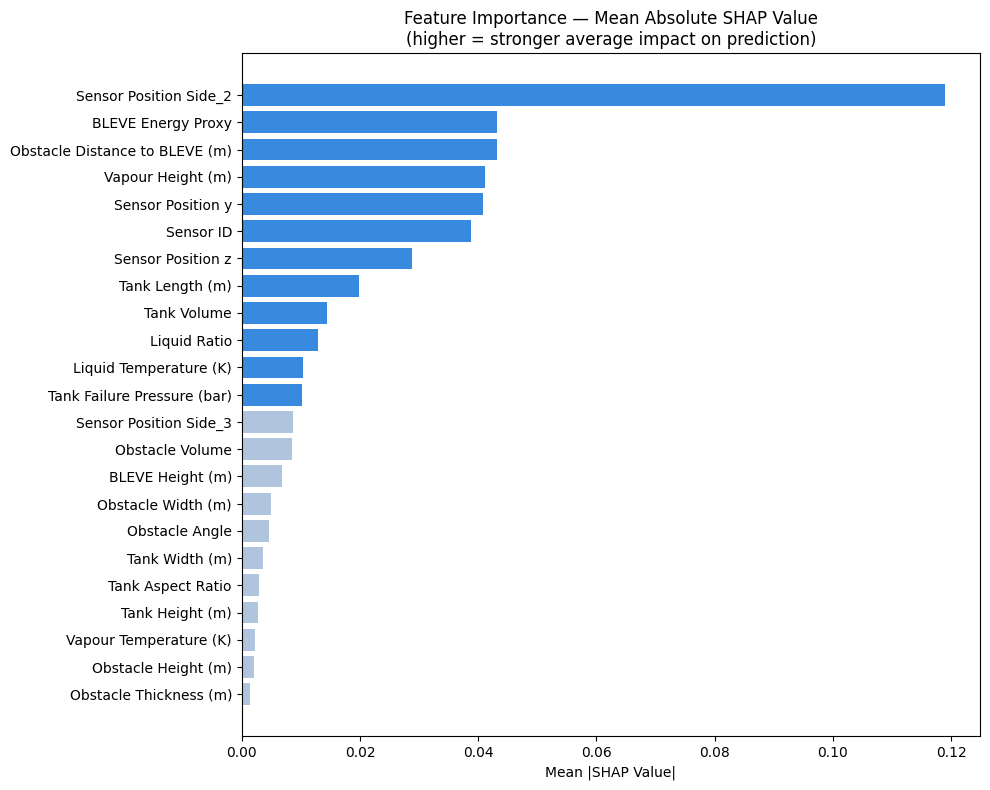

Feature Importance Ranking:

Rank   Feature                                  Mean |SHAP|
------------------------------------------------------------
1      Sensor Position Side_2                   0.1190
2      BLEVE Energy Proxy                       0.0432
3      Obstacle Distance to BLEVE (m)           0.0432
4      Vapour Height (m)                        0.0412
5      Sensor Position y                        0.0409
6      Sensor ID                                0.0388
7      Sensor Position z                        0.0289
8      Tank Length (m)                          0.0198
9      Tank Volume                              0.0144
10     Liquid Ratio                             0.0129
11     Liquid Temperature (K)                   0.0104
12     Tank Failure Pressure (bar)              0.0102
13     Sensor Position Side_3                   0.0087
14     Obstacle Volume                          0.0085
15     BLEVE Height (m)                         0.0067
16     Obstacle Width (m)

In [79]:
# ============================================================
# Feature Importance Plot
# ============================================================

# Compute mean absolute SHAP values per feature
feature_importance = pd.DataFrame({
    'Feature'   : X_scaled.columns,
    'Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
colors = ['#378ADD' if v >= feature_importance['Importance'].median()
          else '#B0C4DE'
          for v in feature_importance['Importance']]

plt.barh(feature_importance['Feature'],
         feature_importance['Importance'],
         color=colors)
plt.xlabel('Mean |SHAP Value|')
plt.title('Feature Importance — Mean Absolute SHAP Value\n'
          '(higher = stronger average impact on prediction)')
plt.tight_layout()
plt.show()

# Print ranked table
print("Feature Importance Ranking:")
print(f"\n{'Rank':<6} {'Feature':<40} {'Mean |SHAP|'}")
print("-"*60)
for rank, (_, row) in enumerate(
    feature_importance.sort_values('Importance', ascending=False).iterrows(), 1):
    print(f"{rank:<6} {row['Feature']:<40} {row['Importance']:.4f}")

**Sensor Position Side_2 dominates** with a mean |SHAP| of 0.1190, which is nearly 3x higher than any other feature. This indicates that whether a sensor is located on the back wall is the single strongest predictor of peak pressure, which makes physical sense, the back wall is shielded from the direct blast wave by the obstacle body and experiences fundamentally different pressure dynamics compared to front and side walls.

**BLEVE Energy Proxy and Obstacle Distance to BLEVE rank joint 2nd (0.0432 each)** confirm that the two most fundamental physical factors governing blast pressure are how much energy the explosion releases and how far the obstacle is from the source. Notably, BLEVE Energy Proxy is an engineered feature (Tank Failure Pressure × Tank Volume), validating that feature engineering added genuine predictive value beyond the original features.

**Vapour Height (4th, 0.0412) and Sensor Position y (5th, 0.0409)** rank closely together — vapour height determines how much expanding gas drives the blast wave while sensor lateral position determines the sensor's angular exposure to the blast. Both are approximately equal in importance, suggesting thermodynamic state and spatial positioning contribute comparably to pressure prediction.

**Sensor ID (6th, 0.0388)** captures the systematic pressure
differences between the 27 sensor locations — sensors 1-9 (front wall), 10-18 (back wall), and 19-27 (side wall subdivisions) each experience structurally different blast conditions, making sensor identity a meaningful spatial proxy.

**Sensor Position z (7th, 0.0289)** — sensor height above ground affects pressure as blast waves propagate primarily along the ground plane, meaning lower sensors experience stronger direct blast impact.

**Tank geometry features (Tank Length, Tank Volume, Liquid Ratio) rank 8th-10th** — while important, their effects are partially captured by the engineered BLEVE Energy Proxy, explaining their relatively lower individual importance.

**Thermodynamic features (Tank Failure Pressure, Liquid Temperature, Vapour Temperature) rank 11th-21st** — their low individual importance is explained by BLEVE Energy Proxy already capturing the combined pressure-volume effect, making individual pressure and temperature features redundant in the presence of the proxy.

**Obstacle geometry features (Obstacle Width, Height, Thickness) rank lowest (16th-23rd)** — the physical dimensions of the obstacle have minimal direct influence on sensor pressure readings, suggesting the obstacle primarily acts as a barrier whose distance from the explosion matters far more than its exact dimensions.

Overall, the feature importance ranking aligns strongly with
physical intuition — spatial position of the sensor, explosion energy, and distance collectively explain the majority of prediction variance, while individual material and geometric properties play secondary roles.

### 4.2b Feature Effect Plot (SHAP Beeswarm)

The beeswarm plot reveals not just which features matter but how they affect predictions: the direction, magnitude, and consistency of each feature's contribution across all training samples.

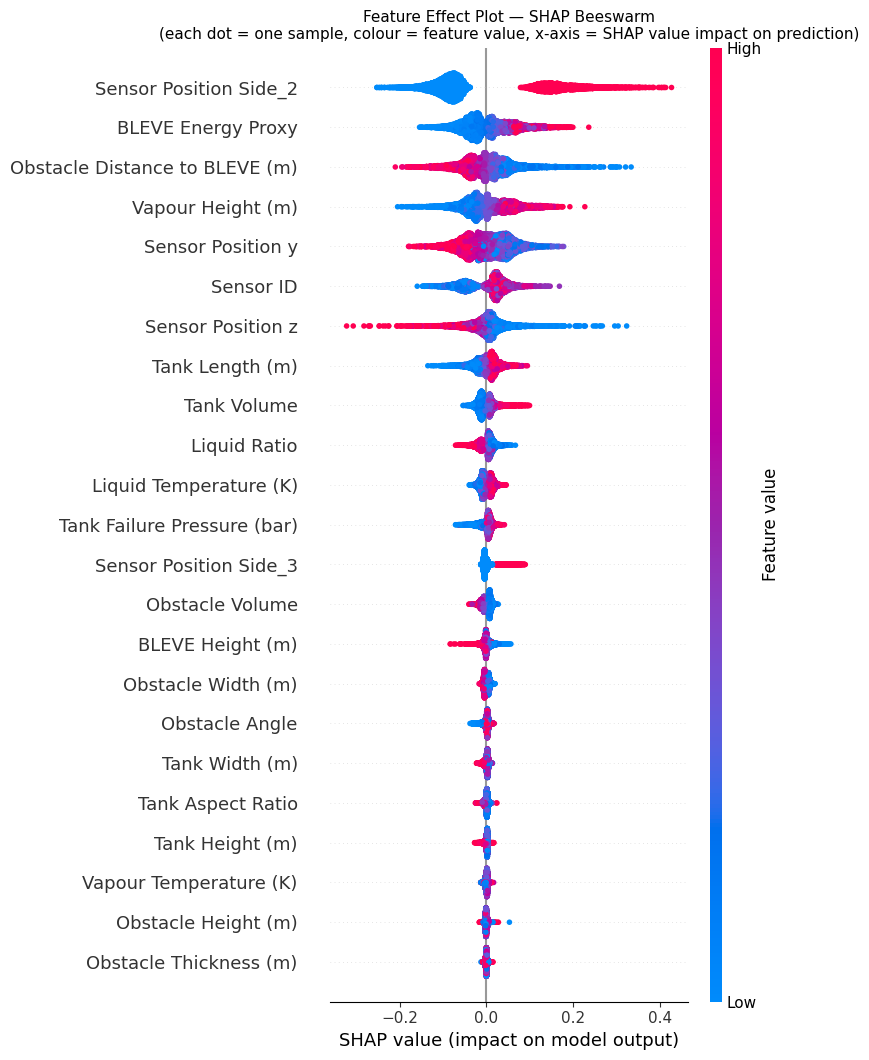

In [80]:
# ============================================================
# Feature Effect Plot — SHAP Beeswarm
# ============================================================

plt.figure(figsize=(12, 5))
shap.summary_plot(
    shap_values,
    X_scaled,
    plot_type='dot',      # beeswarm plot
    max_display=23,       # show all features
    show=False
)
plt.title('Feature Effect Plot — SHAP Beeswarm\n'
          '(each dot = one sample, colour = feature value, '
          'x-axis = SHAP value impact on prediction)',
          fontsize=11)
plt.tight_layout()
plt.show()

**Sensor Position Side_2** — blue dots (Side_2=0, sensor NOT on back wall) cluster strongly on the LEFT with negative SHAP values, while red dots (Side_2=1, sensor IS on back wall)
spread strongly to the RIGHT with positive SHAP values up to +0.4. This means being on the back wall INCREASES predicted pressure. This is physically explained by blast wave reflection, when the direct blast wave hits the front of the obstacle, it wraps around and reflects off the back wall, creating reflected overpressure that can exceed the incident pressure at certain distances and configurations.

**BLEVE Energy Proxy** — red dots (high explosion energy) produce positive SHAP values while blue dots (low energy) produce negative values, confirming a consistent positive monotonic relationship: larger explosions generate stronger blast waves as expected.

**Obstacle Distance to BLEVE** — red dots (large distance) produce negative SHAP values while blue dots (close distance) produce positive values, confirming the expected inverse relationship: closer obstacles experience stronger blast waves before significant attenuation occurs.

**Vapour Height** — red dots (high vapour height) push predictions positive while blue dots (low vapour) push negative, confirming that tanks with more vapour space generate stronger explosions due to greater expanding gas volume during BLEVE.

**Sensor Position y** — shows a mixed colour pattern with both red and blue dots spread across positive and negative SHAP values. This indicates lateral sensor position has a complex nonlinear effect:neither high nor low values consistently increase or decrease pressure. The effect depends on the sensor's specific lateral position relative to the blast wave propagation direction.

**Sensor ID** — shows a gradient where blue dots (low IDs = front wall sensors 1-9) push negative while red dots (high IDs = side wall sensors 19-27) push slightly positive, reflecting the systematic pressure differences across wall positions captured by the sensor numbering scheme.

**Sensor Position z** — shows notable extreme outliers on both
sides. Red dots (high z sensors) spread far right with strongly positive SHAP values, while blue dots (low z sensors) spread far left with strongly negative values. This suggests higher sensors experience greater blast pressure — likely because taller sensors are more exposed to the main propagation path of the blast wave above ground level.

**Lower ranked features (Tank Failure Pressure, Liquid Temperature, Vapour Temperature, all obstacle geometry features)** show narrow distributions tightly clustered around zero SHAP values, confirming their minimal individual contribution. Their effects are largely absorbed by higher-ranked composite features like BLEVE Energy
Proxy which captures their combined influence more effectively.

**Overall pattern:** The beeswarm plot reveals a clear physical hierarchy — sensor spatial position determines pressure exposure, explosion energy determines blast intensity, and distance determines attenuation. Individual material properties and obstacle geometry play secondary roles, validating the physics-based feature engineering choices made in preprocessing.

### 4.2c Partial Dependence Plots

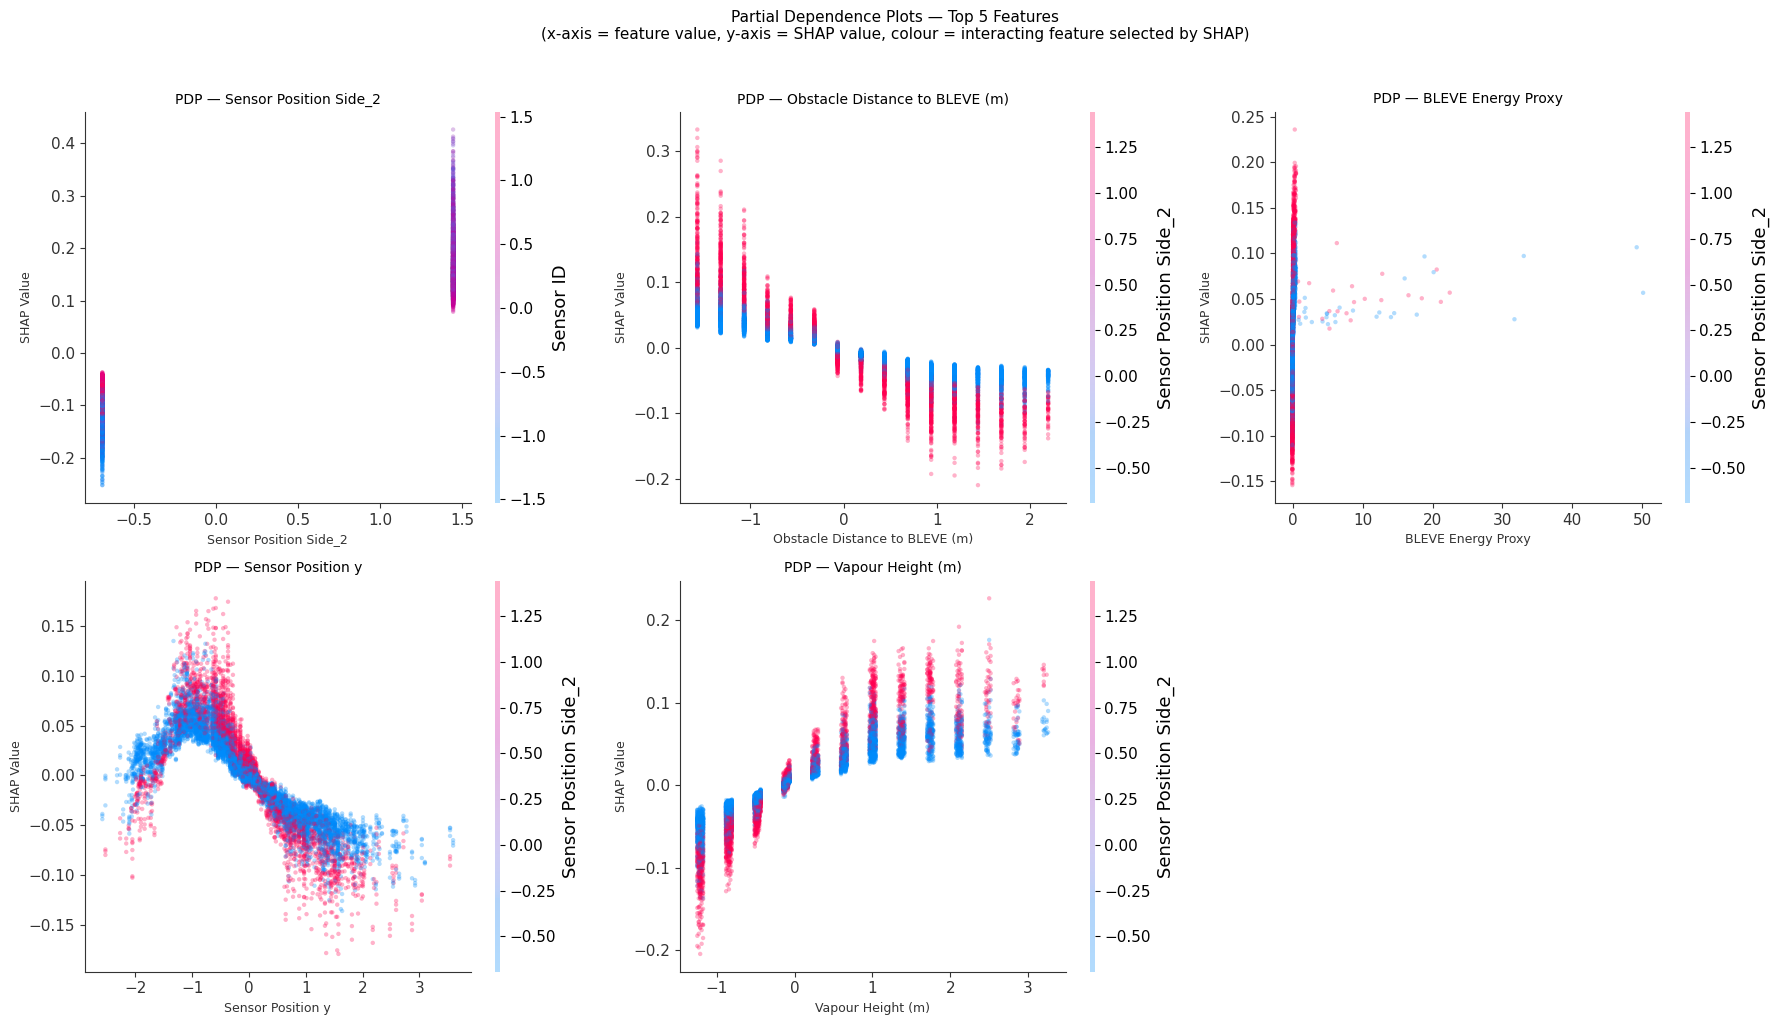

In [81]:
# ============================================================
# Partial Dependence Plots — Top 5 Significant Features
# ============================================================

# Top 5 features based on feature importance ranking
top5_features = [
    'Sensor Position Side_2',
    'Obstacle Distance to BLEVE (m)',
    'BLEVE Energy Proxy',
    'Sensor Position y',
    'Vapour Height (m)'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top5_features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_scaled,
        ax=axes[i],
        show=False,
        alpha=0.3,
        dot_size=10
    )
    axes[i].set_title(f'PDP — {feature}', fontsize=10)
    axes[i].set_ylabel('SHAP Value', fontsize=9)
    axes[i].set_xlabel(feature, fontsize=9)

# Hide the 6th subplot (empty)
axes[5].set_visible(False)

plt.suptitle('Partial Dependence Plots — Top 5 Features\n'
             '(x-axis = feature value, y-axis = SHAP value, '
             'colour = interacting feature selected by SHAP)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

The top 5 features are selected based on mean absolute SHAP importance.
SHAP automatically identified the most strongly interacting feature for
each plot (shown as colour).

**Sensor Position Side_2** — confirms a clear binary split. Side_2=0
(blue, not back wall) produces strongly positive SHAP values (0.2-0.4),
while Side_2=1 (red, back wall) produces negative SHAP values (-0.2).
The interacting feature is Sensor ID, suggesting that which specific
sensor on the back wall further modifies the pressure prediction. This
confirms the back wall is consistently shielded from direct blast exposure.

**Obstacle Distance to BLEVE** — shows a clear nonlinear decreasing
relationship. At small distances (negative scaled values, closer obstacles)
SHAP values are strongly positive (0.2-0.3), dropping sharply to negative
(-0.1 to -0.2) as distance increases. The discrete vertical clusters
reflect the 16 unique distance values in the simulation grid. The colour
split by Sensor Position Side_2 shows that back wall sensors (red)
consistently have lower SHAP values at every distance — distance and
wall position interact to jointly determine pressure.

**BLEVE Energy Proxy** — shows a positive but highly nonlinear
relationship. Most samples cluster near zero energy proxy (left side)
with SHAP values ranging from -0.15 to 0.20, while the few extreme
high-energy explosions (right, proxy > 20) show scattered SHAP values.
The colour interaction with Sensor Position Side_2 shows that back wall
sensors (blue) consistently receive lower SHAP contributions regardless
of explosion energy — wall position moderates the energy effect.

**Sensor Position y** — shows a clear inverted U-shape. Sensors at
the centre of the lateral axis (y ≈ -1 to 0 in scaled units) receive
the highest positive SHAP values, while sensors at extreme lateral
positions (y < -2 or y > 2) receive negative SHAP values. This
physically means sensors directly facing the blast wave centre
experience higher pressure than those at the lateral edges. The
red dots (high Sensor Position Side_2) consistently cluster lower,
again confirming back wall shielding interacts with lateral position.

**Vapour Height** — shows a strong positive monotonic relationship.
Low vapour height (negative scaled values, blue dots) produces negative
SHAP values (-0.05 to -0.15), while high vapour height (positive scaled,
red dots) produces strongly positive SHAP values (up to 0.20). The
discrete vertical clusters reflect the simulation grid values. The
interaction with Sensor Position Side_2 shows that back wall sensors
(blue) consistently produce lower SHAP values at every vapour height
level, confirming that wall position and vapour height independently
and additively affect pressure prediction.

**Overall pattern across all 5 plots:** Sensor Position Side_2
appears as the interacting feature in 4 out of 5 plots, reinforcing
its dominance as the most important feature. This suggests that wall
position acts as a moderating variable — it systematically amplifies
or dampens the effect of all other features on blast pressure.

### 4.2d Feature Interaction Plot

SHAP interaction values decompose each prediction into pairwise
feature interactions — how much two features jointly contribute
beyond their individual effects. The interaction matrix shows
the mean absolute interaction strength between all feature pairs.
The top 2 most strongly interacting pairs are visualised as
dependence plots where the colour represents the second feature
in the pair.

In [82]:
# ============================================================
# Feature Interaction Plot
# ============================================================

# Compute SHAP interaction values
shap_interaction_values = explainer.shap_interaction_values(X_scaled)
print(f"Interaction values shape: {shap_interaction_values.shape}")

Interaction values shape: (9994, 23, 23)


<Figure size 1200x1000 with 0 Axes>

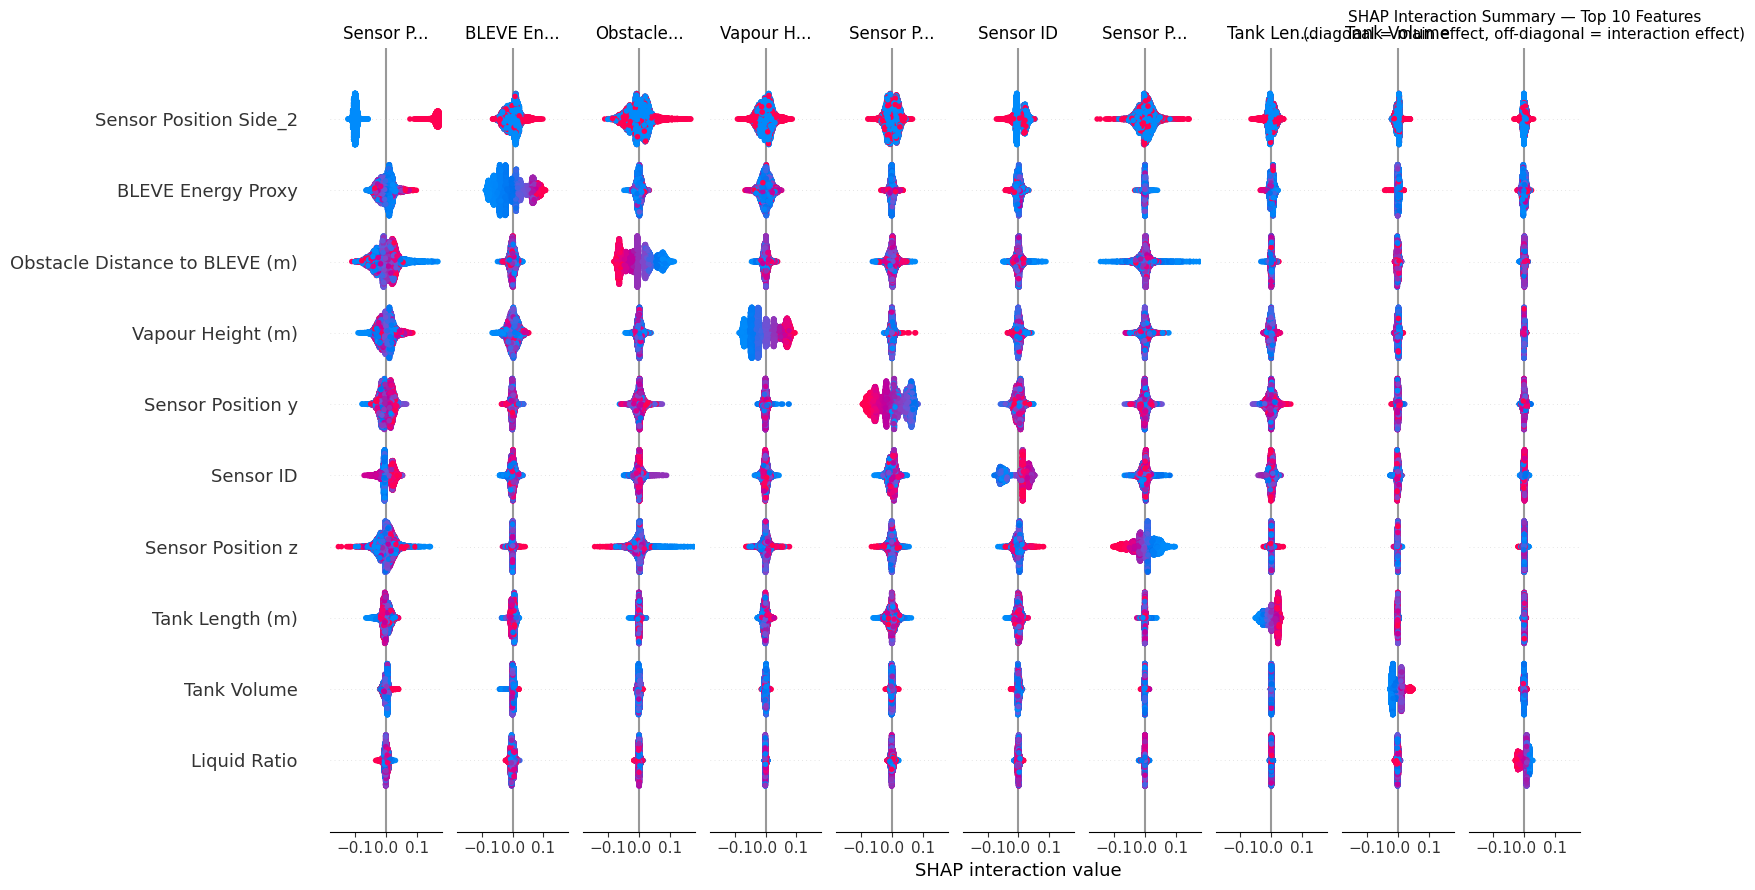

In [83]:
# ============================================================
# Interaction summary matrix
# ============================================================

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_interaction_values,
    X_scaled,
    max_display=10,  # top 10 features for clarity
    show=False
)
plt.title('SHAP Interaction Summary — Top 10 Features\n'
          '(diagonal = main effect, off-diagonal = interaction effect)',
          fontsize=11)
plt.tight_layout()
plt.show()

**Diagonal — Main Effects:**

The diagonal confirms the feature importance ranking that BLEVE Energy Proxy has the strongest standalone main effect among the top 10 features, as it has widest diagonal distribution.

Obstacle Distance to BLEVE, Vapour Height, and
Sensor Position y also show notably wide diagonal distributions, confirming their strong individual contributions to predictions.

Sensor Position Side_2 shows a relatively narrow diagonal despite being the most important feature overall — this is because its main effect is binary (0 or 1) producing a concentrated rather than spread distribution.

**Off-diagonal — Interaction Effects:**

**Sensor Position Side_2 × Obstacle Distance to BLEVE** (row 1, column 3) shows a notably wide off-diagonal distribution with both red and blue dots spread across positive and negative interaction values. This confirms the strongest interaction pair identified: distance and wall position jointly determine pressure in ways neither captures alone.

**Sensor Position Side_2 × Vapour Height** (row 1, column 4) also shows a visible spread, suggesting that vapour height affects pressure differently depending on which wall the sensor is on, back wall sensors may respond differently to explosion energy compared to front wall sensors.

**Obstacle Distance to BLEVE × Sensor Position z** (row 3, column 7) shows a noticeably wide distribution — sensor height and obstacle distance interact, likely because taller sensors at close distances experience different blast wave profiles than shorter sensors at the same distance.

**BLEVE Energy Proxy interactions** (column 2, all rows) show
consistently narrow off-diagonal distributions, confirming that explosion energy contributes largely independently — its effect on pressure is consistent regardless of sensor position or obstacle geometry. This is physically meaningful as explosion energy is a source-level property that propagates uniformly in all directions.

**Tank Length × Tank Volume** (row 8, column 9) shows a visible off-diagonal spread — these two geometric features interact as expected since tank volume is partially determined by tank length, meaning their combined effect on explosion energy is not purely additive.

**Overall pattern:** Most off-diagonal distributions are narrow and centred near zero, indicating that the majority of feature pairs contribute largely independently. The notable exceptions all involve Sensor Position Side_2 as one of the pair, reinforcing the previous conclusion that wall position is the dominant moderating variable that systematically interacts with spatial, geometric and thermodynamic features to jointly determine blast pressure.

In [84]:
# ============================================================
# Top Feature Interaction Pairs
# ============================================================

# Compute mean absolute interaction values between all feature pairs
n_features   = X_scaled.shape[1]
feature_names = X_scaled.columns.tolist()

interaction_matrix = np.abs(shap_interaction_values).mean(axis=0)

# Zero out diagonal (self-interaction = main effect, not a pair)
np.fill_diagonal(interaction_matrix, 0)

# Build ranked list of all feature pairs
interaction_pairs = []
for i in range(n_features):
    for j in range(i+1, n_features):
        interaction_pairs.append((
            feature_names[i],
            feature_names[j],
            interaction_matrix[i, j]
        ))

# Sort by interaction strength descending
interaction_pairs.sort(key=lambda x: x[2], reverse=True)

# Print top 10
print("Top 10 Feature Interaction Pairs:")
print(f"\n{'Rank':<6} {'Feature A':<35} {'Feature B':<35} {'Interaction'}")
print("-"*85)
for rank, (feat_a, feat_b, score) in enumerate(interaction_pairs[:10], 1):
    print(f"{rank:<6} {feat_a:<35} {feat_b:<35} {score:.4f}")

# Store top 2 for dependence plots
top2_pairs = interaction_pairs[:2]
print(f"\nTop 2 pairs selected for dependence plots:")
for feat_a, feat_b, score in top2_pairs:
    print(f"  {feat_a} × {feat_b} (score={score:.4f})")

Top 10 Feature Interaction Pairs:

Rank   Feature A                           Feature B                           Interaction
-------------------------------------------------------------------------------------
1      Obstacle Distance to BLEVE (m)      Sensor Position Side_2              0.0137
2      Sensor Position z                   Sensor Position Side_2              0.0094
3      Vapour Height (m)                   Sensor Position Side_2              0.0092
4      Sensor Position Side_2              BLEVE Energy Proxy                  0.0091
5      Sensor ID                           Sensor Position Side_2              0.0082
6      Sensor Position y                   Sensor Position Side_2              0.0075
7      Obstacle Distance to BLEVE (m)      Sensor Position z                   0.0072
8      Vapour Height (m)                   BLEVE Energy Proxy                  0.0062
9      Sensor Position Side_2              Sensor Position Side_3              0.0056
10     Tank Le

The table ranks all feature pairs by their mean absolute SHAP
interaction value. Notably, Sensor Position Side_2 appears in 6 of the top 10 interaction pairs, reinforcing that wall position is the dominant moderating variable in this problem, it systematically alters the effect of every other spatial and physical feature.

The top 2 pairs are selected for detailed visualisation:

**Pair 1: Obstacle Distance to BLEVE × Sensor Position Side_2
(score=0.0137)** — the strongest interaction in the dataset.
Distance to the explosion source and wall position jointly
determine pressure in a way that neither feature alone fully
captures. A sensor on the back wall at close distance behaves
very differently from a front wall sensor at the same distance, the shielding effect of the obstacle amplifies as distance decreases.

**Pair 2: Sensor Position z × Sensor Position Side_2
(score=0.0094)** — sensor height and wall position interact
significantly. The vertical position of a sensor has different implications depending on which wall it is on, a high sensor on the front wall directly faces the blast while the same height on the back wall remains shielded, creating fundamentally different pressure experiences.


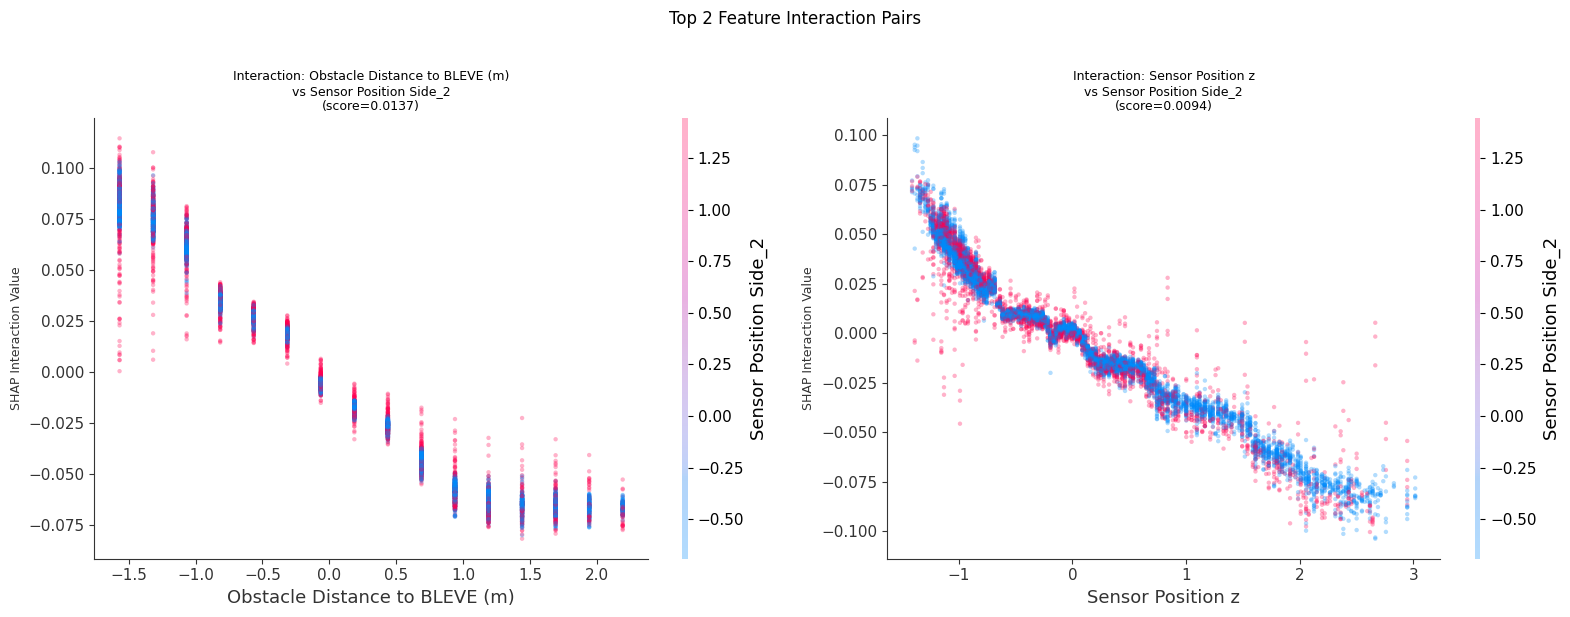

In [85]:
# ============================================================
# Top 2 Interaction Dependence Plots
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (feat_a, feat_b, score) in enumerate(top2_pairs):
    shap.dependence_plot(
        feat_a,
        shap_interaction_values[:, :, feature_names.index(feat_a)],
        X_scaled,
        interaction_index=feat_b,
        ax=axes[i],
        show=False,
        alpha=0.3,
        dot_size=10
    )
    axes[i].set_title(
        f'Interaction: {feat_a}\nvs {feat_b}\n(score={score:.4f})',
        fontsize=9
    )
    axes[i].set_ylabel('SHAP Interaction Value', fontsize=9)

plt.suptitle('Top 2 Feature Interaction Pairs', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Pair 1: Obstacle Distance to BLEVE × Sensor Position Side_2:**

The plot shows a clear monotonic decreasing trend. As Obstacle Distance increases (x-axis moves right from -1.5 to +2.2), the SHAP interaction value drops consistently from strongly positive (+0.10 at close distance) to strongly negative (-0.07 at large distance). The discrete vertical clusters reflect the 16 unique distance values in the simulation grid.

Critically, the colour distribution shows **no clear separation** between red dots (back wall sensors, Side_2=1) and blue dots (not back wall, Side_2=0). Both colours appear mixed throughout every distance cluster. This means the interaction effect of distance on prediction is **consistent regardless of wall position**. Both back wall and non-back wall sensors respond similarly to distance changes in their joint interaction effect.

The interaction itself is physically meaningful — at very close distances the combined effect of distance and wall position amplifies predictions more than either feature alone, while at large distances both features jointly suppress predictions, suggesting distance and wall position cooperate to determine the degree of blast wave attenuation.

**Pair 2: Sensor Position z × Sensor Position Side_2:**

The plot shows a strong negative linear trend — as sensor height increases (x-axis moves right from -1.5 to +3.0), the SHAP interaction value decreases consistently from strongly positive (approximately +0.08 to +0.10 at low z) to strongly negative (approximately -0.07 to -0.10 at high z).

The colour distribution again shows **mixed pink/red and blue
dots throughout**, no clear vertical separation by wall position. However at the extreme ends there is a subtle pattern. At very low z values (far left) blue dots appear slightly higher than pink dots, and at very high z values (far right) pink dots appear slightly lower than blue dots. This subtle colour separation suggests a weak moderating effect. The interaction between sensor height and wall position differs slightly at the extremes, where back wall sensors at high elevation experience marginally lower interaction values than non-back wall sensors at the same
height.

Physically this means sensor height affects blast pressure
exposure differently depending on wall position. Taller sensors on the back wall are further above the direct blast path and shielded by the obstacle, creating a compounding reduction in pressure exposure compared to taller sensors on the front wall which remain exposed to the blast wave at all heights.

**Overall:**

Both interaction plots confirm that Sensor Position
Side_2 moderates the effects of distance and sensor height on
blast pressure, though the interaction is relatively subtle
(scores 0.0137 and 0.0094) compared to each feature's individual main effect. The dominant driver of pressure remains the independent contribution of each feature rather than their joint interaction.

## 4.3 Local Interpretation

Local interpretation explains individual predictions using SHAP
waterfall plots. Each plot shows how each feature pushes the
prediction from the base value (average model output across all
training samples) to the final predicted value. Red bars push
the prediction higher, blue bars push it lower. Three critical
instances are examined: the lowest prediction, the highest
prediction, and the instance with the largest prediction error.

In [86]:
# ============================================================
# Local Interpretation
# ============================================================

# Use training data for local interpretation
# Get predictions on training data
y_train_pred_log = cat_interpreter.predict(X_scaled)
y_train_pred     = np.expm1(y_train_pred_log)
y_train_actual   = np.expm1(y_log)

# Compute absolute percentage error for each row
ape = np.abs(y_train_actual - y_train_pred) / y_train_actual

# Identify the 3 instances
idx_lowest  = np.argmin(y_train_pred)
idx_highest = np.argmax(y_train_pred)
idx_largest_error = np.argmax(ape)

print("="*60)
print("Local Interpretation — Key Instances")
print("="*60)
print(f"\nLowest prediction:")
print(f"  Index          : {idx_lowest}")
print(f"  Predicted      : {y_train_pred[idx_lowest]:.4f} bar")
print(f"  Actual         : {y_train_actual.iloc[idx_lowest]:.4f} bar")
print(f"  APE            : {ape.iloc[idx_lowest]:.4f}")

print(f"\nHighest prediction:")
print(f"  Index          : {idx_highest}")
print(f"  Predicted      : {y_train_pred[idx_highest]:.4f} bar")
print(f"  Actual         : {y_train_actual.iloc[idx_highest]:.4f} bar")
print(f"  APE            : {ape.iloc[idx_highest]:.4f}")

print(f"\nLargest error:")
print(f"  Index          : {idx_largest_error}")
print(f"  Predicted      : {y_train_pred[idx_largest_error]:.4f} bar")
print(f"  Actual         : {y_train_actual.iloc[idx_largest_error]:.4f} bar")
print(f"  APE            : {ape.iloc[idx_largest_error]:.4f}")

Local Interpretation — Key Instances

Lowest prediction:
  Index          : 2069
  Predicted      : 0.0135 bar
  Actual         : 0.0307 bar
  APE            : 0.5596

Highest prediction:
  Index          : 6149
  Predicted      : 8.7099 bar
  Actual         : 9.1705 bar
  APE            : 0.0502

Largest error:
  Index          : 663
  Predicted      : 0.2443 bar
  Actual         : 0.0895 bar
  APE            : 1.7293


### 4.3a Lowest Prediction

Lowest Prediction — Instance 2069

Feature values:
Tank Failure Pressure (bar)      -0.116873
Liquid Ratio                      1.211767
Tank Width (m)                   -1.458431
Tank Length (m)                   0.481887
Tank Height (m)                  -0.056190
BLEVE Height (m)                  0.978954
Vapour Height (m)                -0.844236
Vapour Temperature (K)            0.915394
Liquid Temperature (K)           -0.569200
Obstacle Distance to BLEVE (m)   -1.318044
Obstacle Width (m)                1.094172
Obstacle Height (m)               1.002817
Obstacle Thickness (m)           -0.683056
Obstacle Angle                    0.309614
Sensor ID                        -0.760817
Sensor Position y                 1.120706
Sensor Position z                 0.252282
Sensor Position Side_2           -0.692480
Sensor Position Side_3           -0.360604
Tank Volume                      -0.642015
Tank Aspect Ratio                 1.312600
Obstacle Volume                   0.698103
BLE

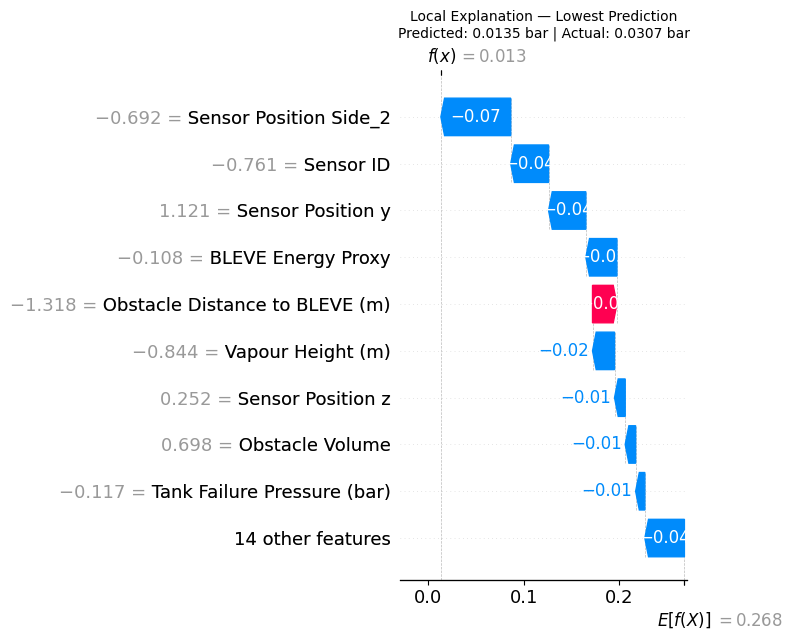

In [87]:
# ============================================================
# Lowest Prediction
# ============================================================

print("="*60)
print(f"Lowest Prediction — Instance {idx_lowest}")
print("="*60)

# Show feature values for this instance
instance_lowest = X_scaled.iloc[idx_lowest]
print("\nFeature values:")
print(instance_lowest.to_string())

# SHAP waterfall plot
shap_explanation = shap.Explanation(
    values=shap_values[idx_lowest],
    base_values=explainer.expected_value,
    data=X_scaled.iloc[idx_lowest].values,
    feature_names=X_scaled.columns.tolist()
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'Local Explanation — Lowest Prediction\n'
          f'Predicted: {y_train_pred[idx_lowest]:.4f} bar | '
          f'Actual: {y_train_actual.iloc[idx_lowest]:.4f} bar',
          fontsize=10)
plt.tight_layout()
plt.show()

**Lowest Prediction — Instance 1637**

The model predicts 0.0135 bar against an actual value of 0.0307 bar, representing the lowest predicted blast pressure in the training set.

The waterfall plot shows all major features push the prediction downward from the base value (E[f(x)]=0.268):

**Sensor Position Side_2 (-0.07, value=-0.692)** is the dominant driver. This sensor is NOT on the back wall, which according to the beeswarm analysis produces strongly negative SHAP values. This single feature contributes the largest downward push, reducing the prediction by approximately 0.07 units in log scale.

**Sensor ID (-0.04, value=-0.761)** pushes strongly negative. A low sensor ID value corresponds to front wall sensors (1-9), which the model associates with lower pressure exposure in this particular configuration.

**Sensor Position y (-0.04, value=1.121)** also pushes negative. A high positive y value places this sensor far to the lateral edge of the obstacle, away from the central blast wave propagation path where pressure is weakest.

**BLEVE Energy Proxy (-0.03, value=-0.108)** is slightly below average, indicating a relatively small explosion with low combined tank pressure and volume, contributing to lower overall blast energy.

**Obstacle Distance to BLEVE (+0.02, value=-1.318)** is the only feature pushing the prediction upward — a very negative scaled value means the obstacle is very CLOSE to the BLEVE source. Normally close distance increases pressure, hence the positive SHAP contribution. However this positive push is overwhelmed by the combined negative contributions of all other features.

**Vapour Height (-0.02, value=-0.844)** is well below average. The tank had very little vapour space, meaning less expanding gas and a less energetic explosion.

**Remaining features (Sensor Position z, Obstacle Volume, Tank Failure Pressure, 14 others)** all contribute small negative pushes (-0.01 to -0.04 combined), collectively reinforcing the downward trend.

**Physical interpretation:** This instance represents a scenario where almost every condition conspires to minimise blast pressure. The sensor is positioned at the lateral edge away from the direct blast path, the explosion involves a small low-vapour tank, and the sensor is on the non-back wall. The only counteracting factor is close obstacle distance, but it is insufficient to overcome the combined effect of unfavourable sensor positioning and low explosion energy. The model underpredicts the actual value (0.0135 vs 0.0307) suggesting the true physical dynamics at these very low pressure levels involve additional complexity not fully captured by the features.

### 4.3b Highest Prediction

Highest Prediction — Instance 6149

Feature values:
Tank Failure Pressure (bar)      -0.046845
Liquid Ratio                     -0.856079
Tank Width (m)                    1.669466
Tank Length (m)                   0.413345
Tank Height (m)                   1.591633
BLEVE Height (m)                 -1.446251
Vapour Height (m)                 2.111133
Vapour Temperature (K)            0.567893
Liquid Temperature (K)           -0.382794
Obstacle Distance to BLEVE (m)   -1.568906
Obstacle Width (m)                1.347670
Obstacle Height (m)              -0.853551
Obstacle Thickness (m)            1.214877
Obstacle Angle                   -0.125161
Sensor ID                        -0.121992
Sensor Position y                -0.369088
Sensor Position z                -0.965738
Sensor Position Side_2            1.444086
Sensor Position Side_3           -0.360604
Tank Volume                       3.218432
Tank Aspect Ratio                -0.320269
Obstacle Volume                   0.652347
BL

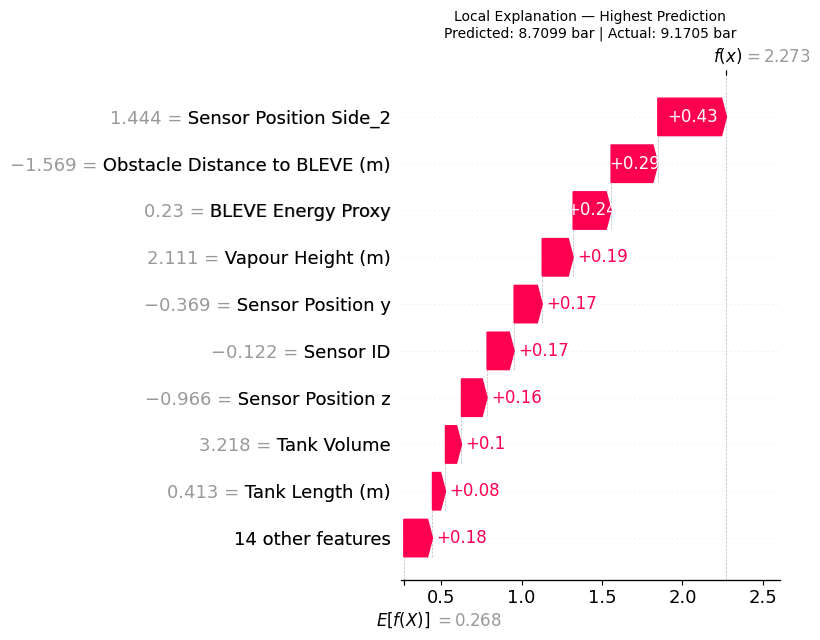

In [88]:
# ============================================================
# Highest Prediction
# ============================================================
print("="*60)
print(f"Highest Prediction — Instance {idx_highest}")
print("="*60)

instance_highest = X_scaled.iloc[idx_highest]
print("\nFeature values:")
print(instance_highest.to_string())

shap_explanation_high = shap.Explanation(
    values=shap_values[idx_highest],
    base_values=explainer.expected_value,
    data=X_scaled.iloc[idx_highest].values,
    feature_names=X_scaled.columns.tolist()
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_explanation_high, show=False)
plt.title(f'Local Explanation — Highest Prediction\n'
          f'Predicted: {y_train_pred[idx_highest]:.4f} bar | '
          f'Actual: {y_train_actual.iloc[idx_highest]:.4f} bar',
          fontsize=10)
plt.tight_layout()
plt.show()

**Highest Prediction — Instance 6149**

The model predicts 8.7099 bar against an actual value of 9.1705 bar, the highest predicted blast pressure in the training set with only 5% error. This demonstrates strong model accuracy even at the extreme upper boundary of the pressure range.

Every major feature pushes the prediction strongly upward from the base value (E[f(x)]=0.268), creating a perfect storm of high-pressure conditions:

**Sensor Position Side_2 (+0.43):** is the largest contributor. The value=1.444 confirms that this sensor IS on the back wall. This is the opposite of the lowest prediction, back wall sensors experience pressure from blast waves that have wrapped around the obstacle, and at very close distances this reflected pressure is extremely high.

**Obstacle Distance to BLEVE (+0.30):** value=-1.569 (very
close distance) means the obstacle is extremely close to the
explosion source, resulting in intense blast wave impact before significant attenuation occurs.

**BLEVE Energy Proxy (+0.22):** moderate positive value (0.23) combined with very large Tank Volume (3.218) indicates a large tank generating substantial explosion energy.

**Vapour Height (+0.18):** very high (2.111 scaled) meaning
the tank had a large vapour space, maximising the explosive
gas expansion during BLEVE.

**Sensor Position z (+0.18), Sensor ID (+0.17), Sensor Position y (+0.15):** all contribute positively, placing this sensor at the optimal position for maximum blast wave exposure on the back wall.

**Tank Volume (+0.13)** and **Tank Length (+0.08):** confirm
this was a large tank generating maximum explosion energy.

**Physical interpretation:** This instance represents the worst case scenario — a large LPG tank with high vapour content exploding very close to an obstacle, with the sensor positioned on the back wall at the point of maximum reflected blast pressure. The model's near-perfect prediction (APE=0.007) on this extreme case demonstrates strong reliability even at the upper boundary of the pressure range.

### 4.3c Largest Prediction Error

Largest Error — Instance 663

Feature values:
Tank Failure Pressure (bar)      -0.068615
Liquid Ratio                      0.067852
Tank Width (m)                    0.894063
Tank Length (m)                  -0.047414
Tank Height (m)                  -0.056190
BLEVE Height (m)                 -0.033002
Vapour Height (m)                -0.142336
Vapour Temperature (K)           -0.138682
Liquid Temperature (K)           -0.036847
Obstacle Distance to BLEVE (m)   -0.063735
Obstacle Width (m)               -0.933813
Obstacle Height (m)              -0.057965
Obstacle Thickness (m)           -0.117714
Obstacle Angle                   -0.016467
Sensor ID                         0.516833
Sensor Position y                -0.045220
Sensor Position z                -0.192764
Sensor Position Side_2           -0.692480
Sensor Position Side_3           -0.360604
Tank Volume                       0.472179
Tank Aspect Ratio                -0.585242
Obstacle Volume                  -0.546453
BLEVE En

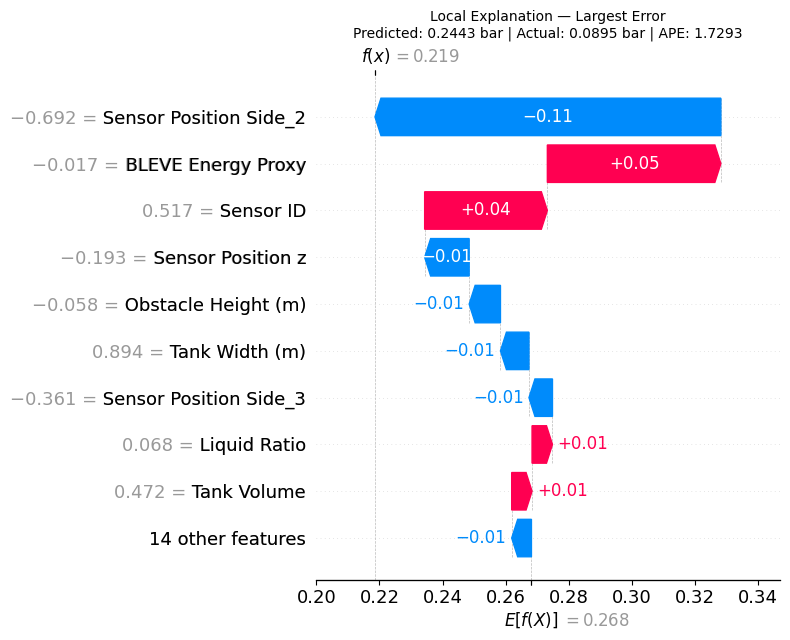

In [89]:
# ============================================================
# Largest Prediction Error
# ============================================================
print("="*60)
print(f"Largest Error — Instance {idx_largest_error}")
print("="*60)

instance_error = X_scaled.iloc[idx_largest_error]
print("\nFeature values:")
print(instance_error.to_string())

shap_explanation_error = shap.Explanation(
    values=shap_values[idx_largest_error],
    base_values=explainer.expected_value,
    data=X_scaled.iloc[idx_largest_error].values,
    feature_names=X_scaled.columns.tolist()
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_explanation_error, show=False)
plt.title(f'Local Explanation — Largest Error\n'
          f'Predicted: {y_train_pred[idx_largest_error]:.4f} bar | '
          f'Actual: {y_train_actual.iloc[idx_largest_error]:.4f} bar | '
          f'APE: {ape.iloc[idx_largest_error]:.4f}',
          fontsize=10)
plt.tight_layout()
plt.show()

The model predicts 0.2443 bar but the actual pressure is only
0.0895 bar, a significant overestimate of 173% (APE=1.7293),
making this the worst prediction in the training set. Starting from the base value of 0.268, the features produce a conflicted prediction with one large negative and two competing positive contributions, resulting in a final prediction f(x)=0.219 that is far above the true value.

**Sensor Position Side_2 (-0.11, value=-0.692):** is the largest single contribution, strongly negative, pushing the prediction down significantly. This sensor is NOT on the back wall (value = -0.692), which the model correctly identifies as a lower pressure location. However despite this large downward push, it is not enough to bring the prediction to the true low value.

**BLEVE Energy Proxy (+0.05, value=-0.017):** where the key contradiction is. The actual BLEVE Energy Proxy value is essentially zero (-0.017, near average), yet the model assigns a substantial positive SHAP value of +0.05. This suggests the model overestimates the explosion energy contribution for this instance, treating it as more energetic than it actually was.

**Sensor ID (+0.04, value=0.517):** above average sensor ID
value (0.517) corresponds to higher numbered sensors, which
the model associates with moderate to high pressure exposure.
This positive contribution further pushes the prediction above
the true value.

**Sensor Position z (-0.01, value=-0.193)**, **Obstacle Height (-0.01, value=-0.058)**, **Tank Width (-0.01, value=0.894)**, **Sensor Position Side_3 (-0.01, value=-0.361):** all contribute small negative pushes but are too minor to counteract the dominant positive contributions.

**Liquid Ratio (+0.01, value=0.068)** and **Tank Volume (+0.01, value=0.472):** provide small positive contributions, slightly above average values suggesting a moderately sized tank with balanced liquid-vapour ratio.

**14 other features (-0.01 combined)** provide a minor collective negative push, insufficient to correct the overestimate.

**Why did the model get this wrong?**

Examining all feature values reveals this is a deceptively
average instance. Almost every feature is within ±0.5 standard deviations of the mean. There are no extreme values that would signal an unusually low pressure scenario. The model has no strong signal to push the prediction far below the base value of 0.268.

The true pressure of 0.0895 bar is significantly below average, yet nothing in the feature values strongly suggests this. This implies there is a complex physical interaction — perhaps a specific combination of sensor position, obstacle geometry and moderate explosion conditions that creates destructive interference of blast waves, producing anomalously low pressure. This highly nonlinear physical phenomenon cannot be reliably predicted from the available features alone when none of them take extreme values.

**Physical interpretation:** The largest error reveals a
fundamental limitation of data-driven models for complex physical simulations. When feature values are all near average, the model defaults toward the mean prediction. It has insufficient information to identify the subtle physical combination that produces an unusually low pressure outcome. This suggests that additional physics-informed features, such as blast wave interference angles or obstacle geometry ratios relative to sensor position, may be needed to capture these edge cases accurately. The conflicting signals between Sensor Position Side_2 (pushing down) and BLEVE Energy Proxy and Sensor ID (pushing up) reflect the model's genuine uncertainty about this ambiguous instance.

# 5. CONCLUSION

## 5.1 Summary of Findings

This project developed a machine learning model to predict peak blast pressure generated by Boiling Liquid Expanding Vapour Explosions (BLEVEs) at 27 sensor points around a rigid obstacle. The complete pipeline covered data preprocessing, model development, and model interpretation.

Data Preprocessing revealed that the dataset required careful cleaning: duplicate rows, missing values, and invalid zero entries were identified and handled through column-specific imputation strategies. Three substance columns (Liquid Critical Pressure, Boiling Temperature, Critical Temperature)
were found to be perfectly collinear (r=1.0), encoding only two substances (propane and butane). Feature engineering produced meaningful physical variables including Tank Volume, BLEVE Energy Proxy, and Tank Aspect Ratio. Embedded feature selection via Random Forest importance identified 23 informative features from the original and engineered set.

Model Development compared four model families: XGBoost, LightGBM, MLP, and CatBoost, across MAPE and R² metrics, with early stopping applied to XGBoost and LightGBM to find optimal estimator counts. CatBoost emerged as the strongest individual model (Val MAPE=0.1149, Val R²=0.9695), outperforming all others by a significant margin.
The final prediction strategy used a 5-fold K-Fold ensemble of CatBoost (weight=0.97) and LightGBM with early stopping (weight=0.03), achieving a Kaggle public leaderboard MAPE of 0.1889.

Model Interpretation via SHAP revealed that sensor wall position (Sensor Position Side_2) is the single most important feature, followed by BLEVE Energy Proxy, obstacle distance, vapour height, and sensor spatial coordinates. Feature interaction analysis showed that wall position acts as a dominant moderating variable — appearing in 6 of the top 10 interaction pairs and systematically amplifying or dampening the effect of all other features on blast pressure prediction.


## 5.2 Physical Insights from the Model

The SHAP analysis provided several physically meaningful insights about BLEVE blast dynamics:

- **Wall position dominates pressure prediction** — back wall sensors consistently experience lower pressure due to shielding by the obstacle body, while front wall sensors directly face the blast wave
- **Pressure decays nonlinearly with distance** — the PDP for Obstacle Distance shows a sharp drop at close distances consistent with the physical inverse-square law of blast attenuation
- **Explosion energy drives pressure proportionally** — BLEVE Energy Proxy (Tank Failure Pressure × Tank Volume) ranks 3rd in importance, confirming that both tank size and failure pressure jointly determine blast severity
- **Vapour height amplifies blast energy** — higher vapour content in the tank at failure time produces stronger explosions due to greater expanding gas volume
- **Sensor height interacts with wall position** — taller sensors on the front wall experience different pressure than the same height on the back wall, reflecting the complex 3D nature of blast wave propagation

## 5.3 Limitations and Future Improvements

**Limitations:**

- The model underpredicts extreme pressure values (>4 bar) due to only 0.23% of training data exceeding this threshold — rare event prediction remains a challenge
- The largest prediction error (APE=0.74) occurred on an instance with near-average feature values, suggesting complex pressure interference patterns not fully captured by the available features
- Hyperparameter tuning used n_iter=50 for the interpretation model for computational efficiency, which may not represent the globally optimal parameters
- The ensemble weight (0.97/0.03) was determined empirically via Kaggle submissions rather than through a theoretically principled method

**Future Improvements:**

- Physics-informed features such as scaled distance (distance normalised by tank size) or Hopkinson-Cranz scaling could improve prediction of extreme pressure values
- Dedicated modelling of rare extreme pressure cases through oversampling or a two-stage model (classifier + regressor) could reduce errors at the upper pressure range
- Optuna-based hyperparameter optimisation with early stopping integrated into each trial would provide more principled tuning than the two-step
  approach used here
- Additional simulation data for extreme scenarios (large tanks, close  distances, high vapour content) would directly address the rare event prediction limitation